In [2]:
from google.colab import drive, files
import zipfile
import os
import numpy as np

import glob
zip_files = glob.glob('*.zip')
print(f"Найдено zip файлов: {zip_files}")

if len(zip_files) == 0:

    print("\nПожалуйста, загрузите zip архив:")
    uploaded = files.upload()
    zip_files = list(uploaded.keys())
    print(f"Загружен файл: {zip_files[0]}")

ZIP_PATH = zip_files[0]
EXTRACT_PATH = '/content/dataset'

print(f"\nРаспаковка {ZIP_PATH}...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
print(f"Распаковано в {EXTRACT_PATH}")

# Проверяем структуру
print("\nСодержимое после распаковки:")
for root, dirs, files in os.walk(EXTRACT_PATH):
    level = root.replace(EXTRACT_PATH, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    for file in files[:5]:  # показываем первые 5 файлов
        print(f'{subindent}{file}')
    if len(files) > 5:
        print(f'{subindent}... и еще {len(files)-5} файлов')


Найдено zip файлов: ['01-20260602T201427Z-3-001.zip']

Распаковка 01-20260602T201427Z-3-001.zip...
Распаковано в /content/dataset

Содержимое после распаковки:
dataset/
  01/
    valve_0492_lidar_classes.ply
    valve_0370_lidar_classes.ply
    valve_0148_lidar_classes.ply
    valve_0106_lidar_classes.ply
    valve_0459_lidar_classes.ply
    ... и еще 498 файлов


In [3]:

ply_files = []
for root, dirs, files in os.walk(EXTRACT_PATH):
    for file in files:
        if file.endswith('.ply'):
            ply_files.append(os.path.join(root, file))

print(f"\nНайдено PLY файлов: {len(ply_files)}")


if len(ply_files) > 0:
    print("\nПримеры файлов:")
    for f in ply_files[:10]:
        print(f"  {os.path.basename(f)} - {os.path.dirname(f)}")
else:
    print("Ошибка: PLY файлы не найдены!")
    print("Проверьте структуру zip архива")


Найдено PLY файлов: 503

Примеры файлов:
  valve_0492_lidar_classes.ply - /content/dataset/01
  valve_0370_lidar_classes.ply - /content/dataset/01
  valve_0148_lidar_classes.ply - /content/dataset/01
  valve_0106_lidar_classes.ply - /content/dataset/01
  valve_0459_lidar_classes.ply - /content/dataset/01
  valve_0016_lidar_classes.ply - /content/dataset/01
  valve_0170_lidar_classes.ply - /content/dataset/01
  valve_0262_lidar_classes.ply - /content/dataset/01
  valve_0381_lidar_classes.ply - /content/dataset/01
  valve_0399_lidar_classes.ply - /content/dataset/01


In [4]:
import numpy as np
import torch
from plyfile import PlyData

def read_ply_pointcloud_with_labels(filepath):
    """
    Загружает PLY файл с полем 'scalar_Label'
    """
    with open(filepath, 'rb') as f:
        plydata = PlyData.read(f)

    # Координаты
    x = plydata['vertex']['x']
    y = plydata['vertex']['y']
    z = plydata['vertex']['z']
    points = np.stack([x, y, z], axis=1).astype(np.float32)

    # Метки - используем правильное имя поля
    if 'scalar_Label' in plydata['vertex'].data.dtype.names:
        labels = plydata['vertex']['scalar_Label'].astype(np.int64)
    elif 'scalar_label' in plydata['vertex'].data.dtype.names:
        labels = plydata['vertex']['scalar_label'].astype(np.int64)
    else:

        label_fields = ['scalar_Label', 'scalar_label', 'label', 'class']
        found = False
        for field in label_fields:
            if field in plydata['vertex'].data.dtype.names:
                labels = plydata['vertex'][field].astype(np.int64)
                found = True
                break
        if not found:
            raise ValueError(f"Не найдено поле с метками. Доступные поля: {plydata['vertex'].data.dtype.names}")

    return points, labels

test_file = '/content/dataset/01/valve_0280_lidar_classes.ply'
points, labels = read_ply_pointcloud_with_labels(test_file)

print(f"Точек: {len(points)}")
print(f"Форма points: {points.shape}")
print(f"Уникальные классы: {np.unique(labels)}")
print(f"Количество классов: {len(np.unique(labels))}")
print(f"\nПервые 10 меток: {labels[:10]}")
print(f"Последние 10 меток: {labels[-10:]}")

Точек: 5185
Форма points: (5185, 3)
Уникальные классы: [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15]
Количество классов: 15

Первые 10 меток: [13 13 13 13 13 13 13 13 13 13]
Последние 10 меток: [5 5 5 4 4 4 6 6 5 4]



Распределение классов в файле:
Класс      Количество   Процент   
-----------------------------------
0          1,542        29.74     %
1          33           0.64      %
2          7            0.14      %
3          9            0.17      %
4          8            0.15      %
5          226          4.36      %
6          124          2.39      %
7          568          10.95     %
8          6            0.12      %
10         840          16.20     %
11         1,341        25.86     %
12         226          4.36      %
13         30           0.58      %
14         38           0.73      %
15         187          3.61      %


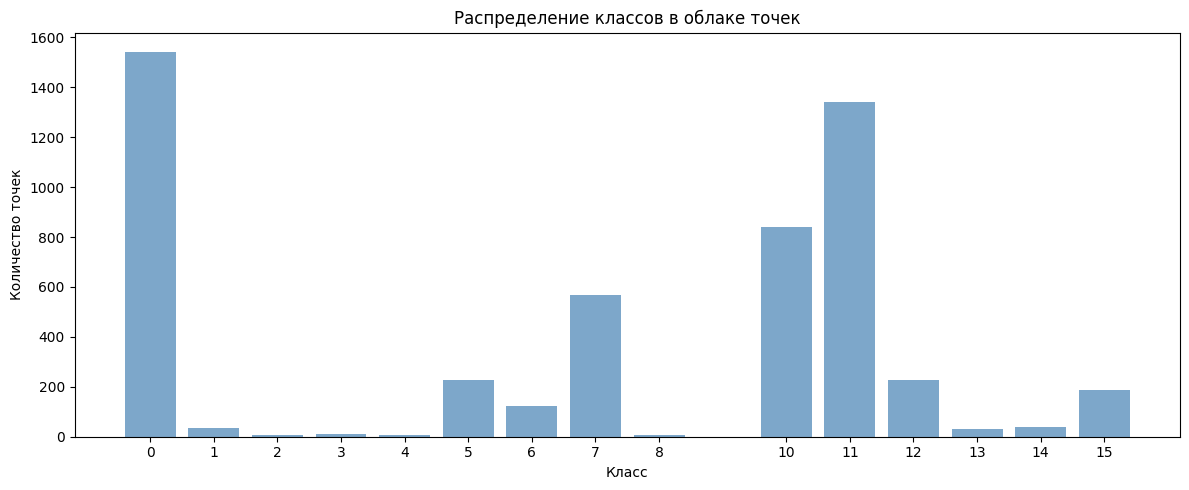

In [5]:

unique, counts = np.unique(labels, return_counts=True)
print("\nРаспределение классов в файле:")
print(f"{'Класс':<10} {'Количество':<12} {'Процент':<10}")
print("-" * 35)
for cls, cnt in zip(unique, counts):
    print(f"{cls:<10} {cnt:<12,} {cnt/len(labels)*100:<10.2f}%")

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Гистограмма распределения классов
plt.bar(unique, counts, alpha=0.7, color='steelblue')
plt.xlabel('Класс')
plt.ylabel('Количество точек')
plt.title('Распределение классов в облаке точек')
plt.xticks(unique)


plt.tight_layout()
plt.show()

In [6]:
import os
import glob
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

# Находим все PLY файлы в распакованной структуре
EXTRACT_PATH = '/content/dataset'
ply_files = glob.glob(f'{EXTRACT_PATH}/**/*.ply', recursive=True)
print(f"Найдено PLY файлов: {len(ply_files)}")

# Показываем несколько примеров
print("\nПримеры файлов:")
for f in ply_files[:10]:
    print(f"  {os.path.relpath(f, EXTRACT_PATH)}")

# Определяем количество классов (проходим по всем файлам)
print("\nОпределяем общее количество классов...")
all_classes = set()
for i, fpath in enumerate(ply_files[:100]):  # проверяем первые 100 файлов
    if i % 20 == 0:
        print(f"  Обработано {i}/{min(100, len(ply_files))} файлов")
    try:
        _, labels = read_ply_pointcloud_with_labels(fpath)
        all_classes.update(np.unique(labels))
    except Exception as e:
        print(f"Ошибка в {fpath}: {e}")

num_classes = len(all_classes)
print(f"\nВсего классов в датасете: {num_classes}")
print(f"Классы: {sorted(all_classes)}")

Найдено PLY файлов: 503

Примеры файлов:
  01/valve_0492_lidar_classes.ply
  01/valve_0370_lidar_classes.ply
  01/valve_0148_lidar_classes.ply
  01/valve_0106_lidar_classes.ply
  01/valve_0459_lidar_classes.ply
  01/valve_0016_lidar_classes.ply
  01/valve_0170_lidar_classes.ply
  01/valve_0262_lidar_classes.ply
  01/valve_0381_lidar_classes.ply
  01/valve_0399_lidar_classes.ply

Определяем общее количество классов...
  Обработано 0/100 файлов
  Обработано 20/100 файлов
  Обработано 40/100 файлов
  Обработано 60/100 файлов
  Обработано 80/100 файлов

Всего классов в датасете: 16
Классы: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]


In [7]:
import os
import glob
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

class LiDARDataset(Dataset):
    def __init__(self, ply_files, num_points=4096, normalize=True, augment=False):
        self.ply_files = ply_files
        self.num_points = num_points
        self.normalize = normalize
        self.augment = augment

        # Предзагружаем данные
        self.data = []
        print(f"Загрузка {len(ply_files)} файлов...")
        for i, fpath in enumerate(ply_files):
            if i % 100 == 0:
                print(f"  Прогресс: {i}/{len(ply_files)}")
            try:
                points, labels = read_ply_pointcloud_with_labels(fpath)
                self.data.append((points, labels))
            except Exception as e:
                print(f"  Ошибка в {fpath}: {e}")
        print(f"Успешно загружено {len(self.data)} объектов")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        points, labels = self.data[idx]

        # Сэмплирование до фиксированного числа точек
        if len(points) > self.num_points:
            indices = np.random.choice(len(points), self.num_points, replace=False)
            points = points[indices]
            labels = labels[indices]
        elif len(points) < self.num_points:
            indices = np.random.choice(len(points), self.num_points, replace=True)
            points = points[indices]
            labels = labels[indices]

        # Нормализация (центрирование и масштабирование)
        if self.normalize:
            centroid = np.mean(points, axis=0)
            points = points - centroid
            max_dist = np.max(np.linalg.norm(points, axis=1))
            if max_dist > 0:
                points = points / max_dist

        # Аугментация (только для обучения)
        if self.augment:
            # Добавляем небольшой шум
            noise = np.random.normal(0, 0.01, points.shape)
            points = points + noise

        # Преобразуем в тензоры
        points = torch.tensor(points, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.long)

        return points, labels

# Разбиение на train/val/test
train_files, temp_files = train_test_split(ply_files, test_size=0.3, random_state=42)
val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

print(f"\nРазбиение датасета:")
print(f"  Train: {len(train_files)} объектов")
print(f"  Val:   {len(val_files)} объектов")
print(f"  Test:  {len(test_files)} объектов")

# Параметры
NUM_POINTS = 4096
BATCH_SIZE = 8

# Создание датасетов
train_dataset = LiDARDataset(train_files, num_points=NUM_POINTS, normalize=True, augment=True)
val_dataset = LiDARDataset(val_files, num_points=NUM_POINTS, normalize=True, augment=False)
test_dataset = LiDARDataset(test_files, num_points=NUM_POINTS, normalize=True, augment=False)

# DataLoader'ы
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Проверка
sample_points, sample_labels = next(iter(train_loader))
print(f"\nПроверка DataLoader:")
print(f"  Batch points shape: {sample_points.shape}")  # [B, N, 3]
print(f"  Batch labels shape: {sample_labels.shape}")  # [B, N]
print(f"  Диапазон координат: [{sample_points.min():.3f}, {sample_points.max():.3f}]")
print(f"  Уникальные классы в батче: {torch.unique(sample_labels)}")


Разбиение датасета:
  Train: 352 объектов
  Val:   75 объектов
  Test:  76 объектов
Загрузка 352 файлов...
  Прогресс: 0/352
  Прогресс: 100/352
  Прогресс: 200/352
  Прогресс: 300/352
Успешно загружено 352 объектов
Загрузка 75 файлов...
  Прогресс: 0/75
Успешно загружено 75 объектов
Загрузка 76 файлов...
  Прогресс: 0/76
Успешно загружено 76 объектов

Проверка DataLoader:
  Batch points shape: torch.Size([8, 4096, 3])
  Batch labels shape: torch.Size([8, 4096])
  Диапазон координат: [-0.926, 0.942]
  Уникальные классы в батче: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, jaccard_score
import seaborn as sns
import time

# Проверка наличия GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Доступно памяти: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Используется устройство: cuda
GPU: Tesla T4
Доступно памяти: 15.64 GB


# PointNet

In [ ]:
class TNet(nn.Module):
    """Transform Network для PointNet"""
    def __init__(self, k=3):
        super(TNet, self).__init__()
        self.k = k
        self.conv1 = nn.Conv1d(k, 64, 1)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.conv3 = nn.Conv1d(128, 1024, 1)

        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, k*k)

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(1024)
        self.bn4 = nn.BatchNorm1d(512)
        self.bn5 = nn.BatchNorm1d(256)

    def forward(self, x):
        batch_size = x.size(0)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = torch.max(x, 2, keepdim=True)[0]
        x = x.view(-1, 1024)

        x = F.relu(self.bn4(self.fc1(x)))
        x = F.relu(self.bn5(self.fc2(x)))
        x = self.fc3(x)

        identity = torch.eye(self.k, device=x.device).view(1, self.k*self.k).repeat(batch_size, 1)
        x = x + identity
        x = x.view(-1, self.k, self.k)
        return x

class PointNetSegmentation(nn.Module):
    """PointNet для семантической сегментации"""
    def __init__(self, num_classes, input_channels=3):
        super(PointNetSegmentation, self).__init__()
        self.num_classes = num_classes
        self.input_channels = input_channels

        # Transform networks
        self.input_transform = TNet(k=input_channels)
        self.feature_transform = TNet(k=64)

        # Point-wise MLP
        self.conv1 = nn.Conv1d(input_channels, 64, 1)
        self.conv2 = nn.Conv1d(64, 64, 1)
        self.conv3 = nn.Conv1d(64, 64, 1)
        self.conv4 = nn.Conv1d(64, 128, 1)
        self.conv5 = nn.Conv1d(128, 1024, 1)

        # Batch norms
        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(64)
        self.bn3 = nn.BatchNorm1d(64)
        self.bn4 = nn.BatchNorm1d(128)
        self.bn5 = nn.BatchNorm1d(1024)

        # Segmentation head
        self.conv6 = nn.Conv1d(1088, 512, 1)  # 1088 = 1024 + 64
        self.conv7 = nn.Conv1d(512, 256, 1)
        self.conv8 = nn.Conv1d(256, 128, 1)
        self.conv9 = nn.Conv1d(128, num_classes, 1)

        self.bn6 = nn.BatchNorm1d(512)
        self.bn7 = nn.BatchNorm1d(256)
        self.bn8 = nn.BatchNorm1d(128)

        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        # x: (B, N, 3) -> (B, 3, N)
        x = x.transpose(1, 2)
        batch_size = x.size(0)
        num_points = x.size(2)

        # Input transform
        trans_input = self.input_transform(x)
        x = torch.bmm(trans_input, x)

        # Point features
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        # Store local features for skip connection
        local_features = x

        # Feature transform
        trans_feat = self.feature_transform(x)
        x = torch.bmm(trans_feat, x)

        # Global features
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))
        global_features = torch.max(x, 2, keepdim=True)[0]
        global_features = global_features.repeat(1, 1, num_points)

        # Concatenate local and global features
        x = torch.cat([local_features, global_features], dim=1)

        # Segmentation MLP
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.dropout(x)
        x = F.relu(self.bn7(self.conv7(x)))
        x = self.dropout(x)
        x = F.relu(self.bn8(self.conv8(x)))
        x = self.conv9(x)

        # Output: (B, num_classes, N) -> (B, N, num_classes)
        x = x.transpose(1, 2)

        return x

# Создаем модель
model = PointNetSegmentation(num_classes=num_classes, input_channels=3).to(device)
print(f"Модель создана. Количество параметров: {sum(p.numel() for p in model.parameters()):,}")
print(model)

Модель создана. Количество параметров: 3,537,753
PointNetSegmentation(
  (input_transform): TNet(
    (conv1): Conv1d(3, 64, kernel_size=(1,), stride=(1,))
    (conv2): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
    (conv3): Conv1d(128, 1024, kernel_size=(1,), stride=(1,))
    (fc1): Linear(in_features=1024, out_features=512, bias=True)
    (fc2): Linear(in_features=512, out_features=256, bias=True)
    (fc3): Linear(in_features=256, out_features=9, bias=True)
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn3): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (feature_transform): TNet(
    (conv1): Conv1d(64, 64, kernel_siz

In [ ]:
class MetricsCalculator:
    """Класс для расчета метрик"""
    def __init__(self, num_classes):
        self.num_classes = num_classes

    def calculate(self, predictions, targets):
        """
        predictions: (N,) предсказанные классы
        targets: (N,) истинные классы
        """
        # Overall accuracy
        accuracy = accuracy_score(targets, predictions)

        # Per-class IoU и F1
        per_class_iou = {}
        per_class_f1 = {}

        for c in range(self.num_classes):
            # IoU
            intersection = ((predictions == c) & (targets == c)).sum()
            union = ((predictions == c) | (targets == c)).sum()
            iou = intersection / union if union > 0 else 0
            per_class_iou[c] = iou

            # F1 score
            tp = ((predictions == c) & (targets == c)).sum()
            fp = ((predictions == c) & (targets != c)).sum()
            fn = ((predictions != c) & (targets == c)).sum()
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            per_class_f1[c] = f1

        # Mean IoU
        mean_iou = np.mean(list(per_class_iou.values()))

        # Mean F1
        mean_f1 = np.mean(list(per_class_f1.values()))

        return {
            'accuracy': accuracy,
            'mean_iou': mean_iou,
            'mean_f1': mean_f1,
            'per_class_iou': per_class_iou,
            'per_class_f1': per_class_f1
        }

def train_epoch(model, train_loader, criterion, optimizer, device, metrics_calc):
    """Одна эпоха обучения"""
    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []

    pbar = tqdm(train_loader, desc="Training")
    for points, labels in pbar:
        points, labels = points.to(device), labels.to(device)

        # Forward pass
        outputs = model(points)
        loss = criterion(outputs.permute(0, 2, 1), labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Collect predictions
        preds = torch.argmax(outputs, dim=2)
        all_preds.extend(preds.cpu().numpy().flatten())
        all_targets.extend(labels.cpu().numpy().flatten())

        total_loss += loss.item()
        pbar.set_postfix({'loss': loss.item()})

    # Calculate metrics
    metrics = metrics_calc.calculate(np.array(all_preds), np.array(all_targets))
    metrics['loss'] = total_loss / len(train_loader)

    return metrics

def validate_epoch(model, val_loader, criterion, device, metrics_calc):
    """Валидация"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(val_loader, desc="Validation")
        for points, labels in pbar:
            points, labels = points.to(device), labels.to(device)

            outputs = model(points)
            loss = criterion(outputs.permute(0, 2, 1), labels)

            preds = torch.argmax(outputs, dim=2)
            all_preds.extend(preds.cpu().numpy().flatten())
            all_targets.extend(labels.cpu().numpy().flatten())

            total_loss += loss.item()

    metrics = metrics_calc.calculate(np.array(all_preds), np.array(all_targets))
    metrics['loss'] = total_loss / len(val_loader)

    return metrics

In [ ]:
# Параметры обучения
num_epochs = 50
learning_rate = 0.001
weight_decay = 1e-4

# Функция потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# Метрики
metrics_calc = MetricsCalculator(num_classes)

# Хранение истории обучения
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_miou': [], 'val_miou': [],
    'train_mf1': [], 'val_mf1': []
}

best_val_miou = 0
best_model_path = '/content/best_pointnet.pth'

print("Начинаем обучение...")
print("="*60)

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-"*40)

    # Обучение
    train_metrics = train_epoch(model, train_loader, criterion, optimizer, device, metrics_calc)
    # Валидация
    val_metrics = validate_epoch(model, val_loader, criterion, device, metrics_calc)

    # Сохраняем историю
    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics['loss'])
    history['train_acc'].append(train_metrics['accuracy'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['train_miou'].append(train_metrics['mean_iou'])
    history['val_miou'].append(val_metrics['mean_iou'])
    history['train_mf1'].append(train_metrics['mean_f1'])
    history['val_mf1'].append(val_metrics['mean_f1'])

    # Выводим результаты
    print(f"Train - Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, "
          f"mIoU: {train_metrics['mean_iou']:.4f}, mF1: {train_metrics['mean_f1']:.4f}")
    print(f"Val   - Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, "
          f"mIoU: {val_metrics['mean_iou']:.4f}, mF1: {val_metrics['mean_f1']:.4f}")

    # Выводим per-class метрики для валидации (каждые 10 эпох)
    if (epoch + 1) % 10 == 0:
        print("\nPer-class IoU on validation:")
        for c in range(num_classes):
            print(f"  Class {c}: {val_metrics['per_class_iou'][c]:.4f}")

    # Сохраняем лучшую модель
    if val_metrics['mean_iou'] > best_val_miou:
        best_val_miou = val_metrics['mean_iou']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_miou': val_metrics['mean_iou'],
            'val_acc': val_metrics['accuracy']
        }, best_model_path)
        print(f"  ✓ Сохранена лучшая модель (mIoU: {best_val_miou:.4f})")

    # Обновляем learning rate
    scheduler.step()

print("\n" + "="*60)
print("Обучение завершено!")
print(f"Лучшая mIoU на валидации: {best_val_miou:.4f}")

Начинаем обучение...

Epoch 1/50
----------------------------------------


Validation: 100%|██████████| 10/10 [00:00<00:00, 19.15it/s]


Train - Loss: 1.5395, Acc: 0.5538, mIoU: 0.1285, mF1: 0.1819
Val   - Loss: 0.9883, Acc: 0.6921, mIoU: 0.1754, mF1: 0.2236
  ✓ Сохранена лучшая модель (mIoU: 0.1754)

Epoch 2/50
----------------------------------------


Validation: 100%|██████████| 10/10 [00:00<00:00, 19.76it/s]


Train - Loss: 0.7373, Acc: 0.7752, mIoU: 0.2180, mF1: 0.2551
Val   - Loss: 0.6831, Acc: 0.7742, mIoU: 0.2180, mF1: 0.2538
  ✓ Сохранена лучшая модель (mIoU: 0.2180)

Epoch 3/50
----------------------------------------


...

Train - Loss: 0.1050, Acc: 0.9575, mIoU: 0.7733, mF1: 0.8527
Val   - Loss: 0.0774, Acc: 0.9690, mIoU: 0.8353, mF1: 0.8987
  ✓ Сохранена лучшая модель (mIoU: 0.8353)

Epoch 49/50
----------------------------------------


Validation: 100%|██████████| 10/10 [00:00<00:00, 17.39it/s]


Train - Loss: 0.1002, Acc: 0.9597, mIoU: 0.7888, mF1: 0.8652
Val   - Loss: 0.0751, Acc: 0.9716, mIoU: 0.8449, mF1: 0.9084
  ✓ Сохранена лучшая модель (mIoU: 0.8449)

Epoch 50/50
----------------------------------------


Validation: 100%|██████████| 10/10 [00:00<00:00, 17.10it/s]


Train - Loss: 0.1016, Acc: 0.9590, mIoU: 0.7851, mF1: 0.8623
Val   - Loss: 0.0698, Acc: 0.9738, mIoU: 0.8434, mF1: 0.9026

Per-class IoU on validation:
  Class 0: 0.9583
  Class 1: 0.3616
  Class 2: 0.5315
  Class 3: 0.9238
  Class 4: 0.8631
  Class 5: 0.9411
  Class 6: 0.7930
  Class 7: 0.9337
  Class 8: 0.6234
  Class 9: 0.7492
  Class 10: 0.9548
  Class 11: 0.9686
  Class 12: 0.9686
  Class 13: 0.9774
  Class 14: 0.9806
  Class 15: 0.9660

Обучение завершено!
Лучшая mIoU на валидации: 0.8449


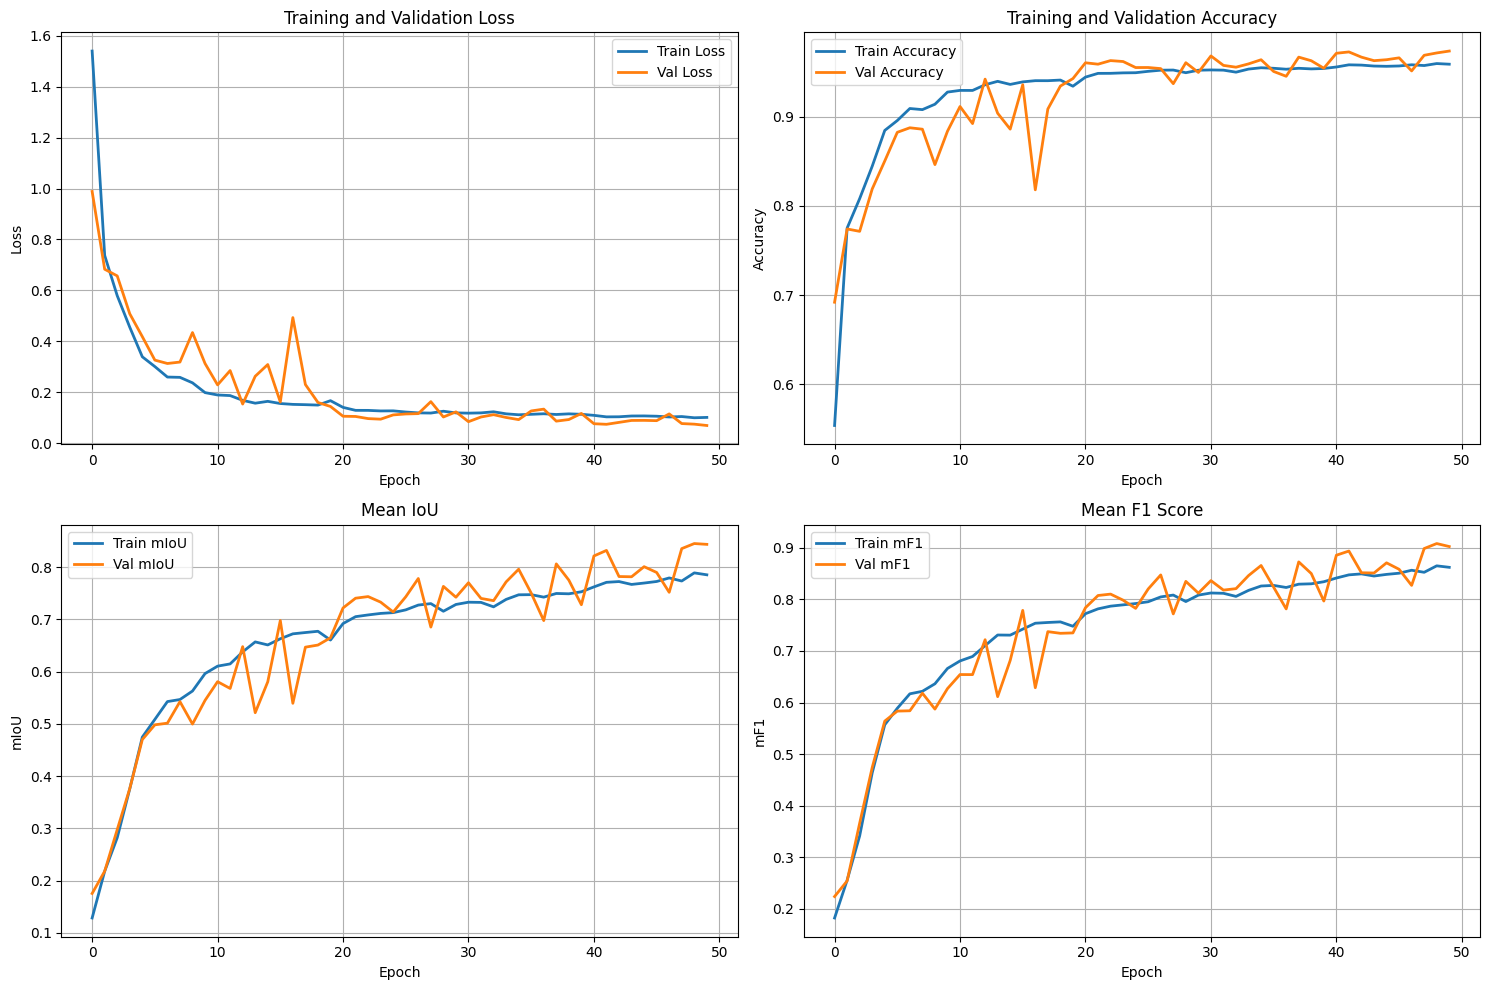

In [ ]:
# Графики обучения
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# mIoU
axes[1, 0].plot(history['train_miou'], label='Train mIoU', linewidth=2)
axes[1, 0].plot(history['val_miou'], label='Val mIoU', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('mIoU')
axes[1, 0].set_title('Mean IoU')
axes[1, 0].legend()
axes[1, 0].grid(True)

# mF1
axes[1, 1].plot(history['train_mf1'], label='Train mF1', linewidth=2)
axes[1, 1].plot(history['val_mf1'], label='Val mF1', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('mF1')
axes[1, 1].set_title('Mean F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=150)
plt.show()

In [ ]:
# Загрузка лучшей модели
checkpoint = torch.load(best_model_path, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Загружена лучшая модель с эпохи {checkpoint['epoch']+1}")
print(f"Val mIoU: {checkpoint['val_miou']:.4f}, Val Acc: {checkpoint['val_acc']:.4f}")

# Оценка на тестовом наборе
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    pbar = tqdm(test_loader, desc="Testing")
    for points, labels in pbar:
        points = points.to(device)
        outputs = model(points)
        preds = torch.argmax(outputs, dim=2)

        all_preds.extend(preds.cpu().numpy().flatten())
        all_targets.extend(labels.numpy().flatten())

# Расчет метрик
test_metrics = metrics_calc.calculate(np.array(all_preds), np.array(all_targets))

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ НА ТЕСТОВОМ НАБОРЕ:")
print("="*60)
print(f"Overall Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Mean IoU (mIoU): {test_metrics['mean_iou']:.4f}")
print(f"Mean F1 Score: {test_metrics['mean_f1']:.4f}")
print("\nPer-class IoU:")
for c in range(num_classes):
    print(f"  Class {c}: {test_metrics['per_class_iou'][c]:.4f}")
print("\nPer-class F1 Score:")
for c in range(num_classes):
    print(f"  Class {c}: {test_metrics['per_class_f1'][c]:.4f}")

Загружена лучшая модель с эпохи 49
Val mIoU: 0.8449, Val Acc: 0.9716


Testing: 100%|██████████| 10/10 [00:00<00:00, 10.05it/s]



РЕЗУЛЬТАТЫ НА ТЕСТОВОМ НАБОРЕ:
Overall Accuracy: 0.9715
Mean IoU (mIoU): 0.8288
Mean F1 Score: 0.8962

Per-class IoU:
  Class 0: 0.9533
  Class 1: 0.5620
  Class 2: 0.4948
  Class 3: 0.9055
  Class 4: 0.7831
  Class 5: 0.8990
  Class 6: 0.7389
  Class 7: 0.9204
  Class 8: 0.5641
  Class 9: 0.6277
  Class 10: 0.9587
  Class 11: 0.9725
  Class 12: 0.9761
  Class 13: 0.9741
  Class 14: 0.9750
  Class 15: 0.9562

Per-class F1 Score:
  Class 0: 0.9761
  Class 1: 0.7196
  Class 2: 0.6620
  Class 3: 0.9504
  Class 4: 0.8784
  Class 5: 0.9468
  Class 6: 0.8498
  Class 7: 0.9585
  Class 8: 0.7213
  Class 9: 0.7713
  Class 10: 0.9789
  Class 11: 0.9861
  Class 12: 0.9879
  Class 13: 0.9869
  Class 14: 0.9874
  Class 15: 0.9776


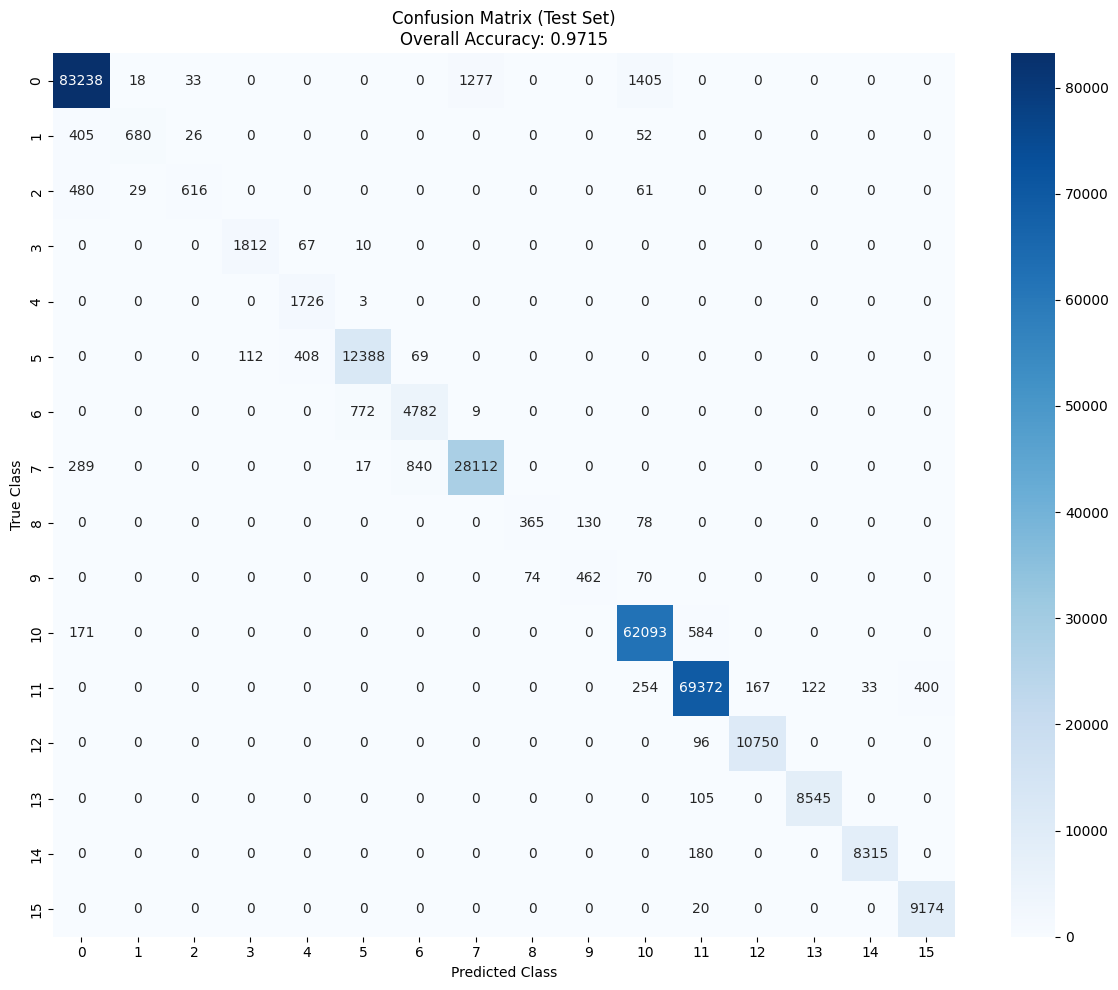

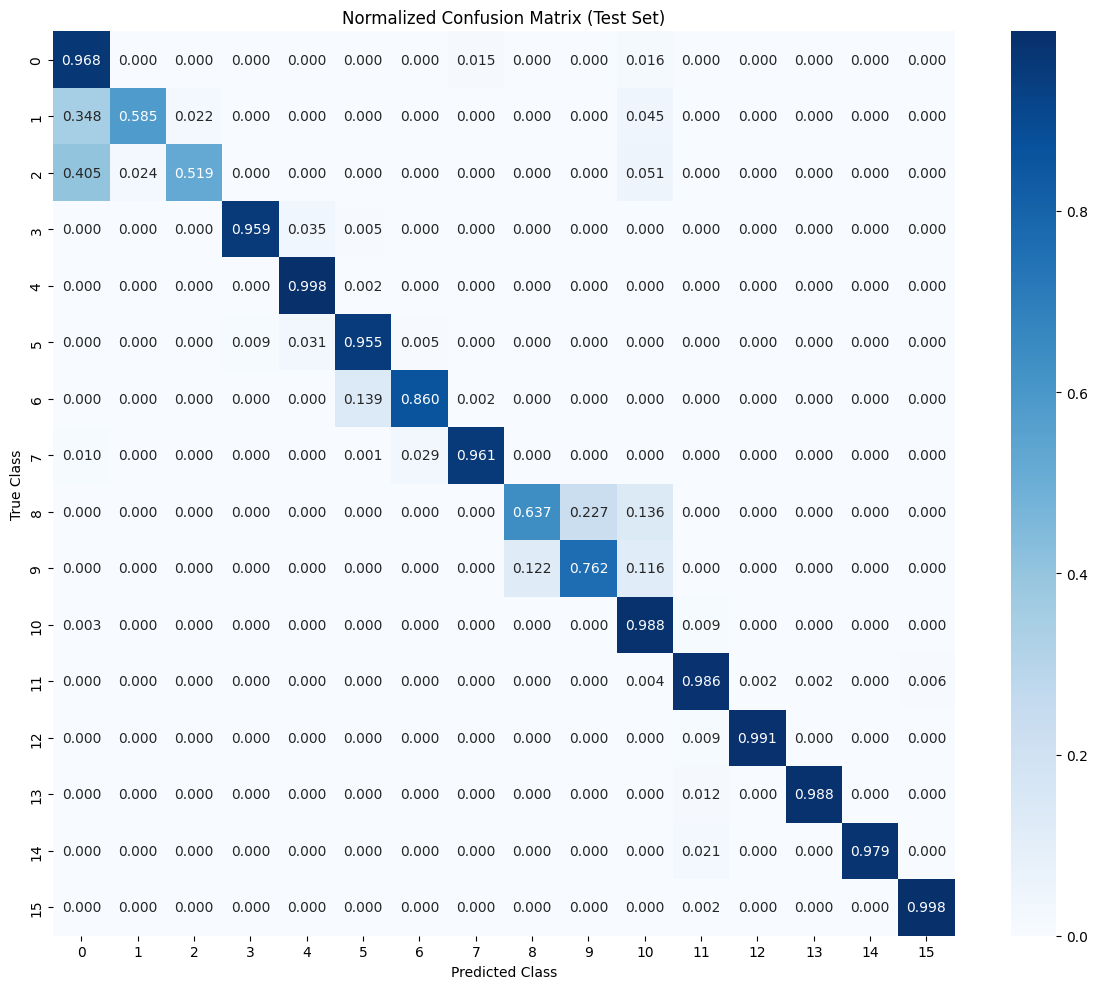

In [ ]:
# Матрица ошибок
cm = confusion_matrix(all_targets, all_preds, labels=range(num_classes))

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(num_classes),
            yticklabels=range(num_classes))
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title(f'Confusion Matrix (Test Set)\nOverall Accuracy: {test_metrics["accuracy"]:.4f}')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

# Нормализованная матрица ошибок
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=range(num_classes),
            yticklabels=range(num_classes))
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title(f'Normalized Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig('/content/confusion_matrix_normalized.png', dpi=150)
plt.show()

In [ ]:
# Сохраняем все результаты
results = {
    'test_metrics': {
        'accuracy': float(test_metrics['accuracy']),
        'mean_iou': float(test_metrics['mean_iou']),
        'mean_f1': float(test_metrics['mean_f1']),
        'per_class_iou': {int(k): float(v) for k, v in test_metrics['per_class_iou'].items()},
        'per_class_f1': {int(k): float(v) for k, v in test_metrics['per_class_f1'].items()}
    },
    'best_val_miou': float(best_val_miou),
    'num_classes': num_classes,
    'training_history': {
        'train_loss': history['train_loss'],
        'val_loss': history['val_loss'],
        'train_acc': history['train_acc'],
        'val_acc': history['val_acc'],
        'train_miou': history['train_miou'],
        'val_miou': history['val_miou']
    }
}

import json
with open('/content/pointnet_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Результаты сохранены в /content/pointnet_results.json")

# Вывод итоговой таблицы
print("\n" + "="*60)
print("ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*60)
print(f"{'Метрика':<20} {'Значение':<15}")
print("-"*35)
print(f"{'Overall Accuracy':<20} {test_metrics['accuracy']:<15.4f}")
print(f"{'Mean IoU (mIoU)':<20} {test_metrics['mean_iou']:<15.4f}")
print(f"{'Mean F1 Score':<20} {test_metrics['mean_f1']:<15.4f}")
print("-"*35)
print("\nPer-class IoU:")
for c in range(num_classes):
    print(f"  Class {c}: {test_metrics['per_class_iou'][c]:.4f}")

Результаты сохранены в /content/pointnet_results.json

ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
Метрика              Значение       
-----------------------------------
Overall Accuracy     0.9715         
Mean IoU (mIoU)      0.8288         
Mean F1 Score        0.8962         
-----------------------------------

Per-class IoU:
  Class 0: 0.9533
  Class 1: 0.5620
  Class 2: 0.4948
  Class 3: 0.9055
  Class 4: 0.7831
  Class 5: 0.8990
  Class 6: 0.7389
  Class 7: 0.9204
  Class 8: 0.5641
  Class 9: 0.6277
  Class 10: 0.9587
  Class 11: 0.9725
  Class 12: 0.9761
  Class 13: 0.9741
  Class 14: 0.9750
  Class 15: 0.9562


#DGCNN

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, jaccard_score
import matplotlib.pyplot as plt
import seaborn as sns

class SimpleDGCNN(nn.Module):
    """Упрощенная и исправленная версия DGCNN"""
    def __init__(self, num_classes, k=20, input_channels=3):
        super(SimpleDGCNN, self).__init__()
        self.k = k

        # EdgeConv слои
        self.bn1 = nn.BatchNorm2d(64)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.bn4 = nn.BatchNorm2d(256)

        self.conv1 = nn.Sequential(
            nn.Conv2d(input_channels*2, 64, kernel_size=1, bias=False),
            self.bn1,
            nn.LeakyReLU(negative_slope=0.2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(64*2, 64, kernel_size=1, bias=False),
            self.bn2,
            nn.LeakyReLU(negative_slope=0.2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64*2, 128, kernel_size=1, bias=False),
            self.bn3,
            nn.LeakyReLU(negative_slope=0.2)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(128*2, 256, kernel_size=1, bias=False),
            self.bn4,
            nn.LeakyReLU(negative_slope=0.2)
        )

        # Глобальный pooling
        self.conv5 = nn.Sequential(
            nn.Conv1d(64+64+128+256, 1024, kernel_size=1, bias=False),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(negative_slope=0.2)
        )

        # Сегментационная головка
        self.seg_conv = nn.Sequential(
            nn.Conv1d(1024+64+64+128+256, 512, kernel_size=1),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Dropout(0.5),
            nn.Conv1d(512, 256, kernel_size=1),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Dropout(0.5),
            nn.Conv1d(256, num_classes, kernel_size=1)
        )

    def get_graph_feature(self, x, k=20):
        """
        Построение признаков графа
        x: (B, N, C)
        """
        batch_size, num_points, num_dims = x.shape
        device = x.device

        # Находим k ближайших соседей
        # Вычисляем попарные расстояния
        dist = torch.cdist(x, x)  # (B, N, N)

        # Находим индексы k ближайших соседей (исключая себя)
        _, idx = torch.topk(dist, k=k+1, dim=-1, largest=False)
        idx = idx[:, :, 1:]  # (B, N, k)

        # Собираем признаки соседей
        neighbors = []
        for i in range(k):
            neighbor_idx = idx[:, :, i:i+1]  # (B, N, 1)
            neighbor = torch.gather(x, 1, neighbor_idx.expand(-1, -1, num_dims))
            neighbors.append(neighbor)

        neighbors = torch.stack(neighbors, dim=2)  # (B, N, k, C)

        # Вычисляем разницу и конкатенируем
        x_expanded = x.unsqueeze(2).expand(-1, -1, k, -1)  # (B, N, k, C)
        edge_features = torch.cat([neighbors - x_expanded, x_expanded], dim=-1)  # (B, N, k, 2C)

        # Переставляем размерности для Conv2d: (B, 2C, N, k)
        edge_features = edge_features.permute(0, 3, 1, 2)

        return edge_features

    def forward(self, x):
        """
        x: (B, N, 3)
        """
        # EdgeConv блок 1
        x1 = self.get_graph_feature(x, self.k)
        x1 = self.conv1(x1)
        x1 = x1.max(dim=-1, keepdim=False)[0]  # (B, 64, N)

        # EdgeConv блок 2
        x1_t = x1.permute(0, 2, 1)  # (B, N, 64)
        x2 = self.get_graph_feature(x1_t, self.k)
        x2 = self.conv2(x2)
        x2 = x2.max(dim=-1, keepdim=False)[0]  # (B, 64, N)

        # EdgeConv блок 3
        x2_t = x2.permute(0, 2, 1)  # (B, N, 64)
        x3 = self.get_graph_feature(x2_t, self.k)
        x3 = self.conv3(x3)
        x3 = x3.max(dim=-1, keepdim=False)[0]  # (B, 128, N)

        # EdgeConv блок 4
        x3_t = x3.permute(0, 2, 1)  # (B, N, 128)
        x4 = self.get_graph_feature(x3_t, self.k)
        x4 = self.conv4(x4)
        x4 = x4.max(dim=-1, keepdim=False)[0]  # (B, 256, N)

        # Агрегация всех признаков
        x_concat = torch.cat((x1, x2, x3, x4), dim=1)  # (B, 64+64+128+256=512, N)

        # Глобальный признак
        x_global = self.conv5(x_concat)
        x_global = x_global.max(dim=-1, keepdim=True)[0]  # (B, 1024, 1)
        x_global = x_global.expand(-1, -1, x_concat.size(-1))  # (B, 1024, N)

        # Сегментация
        x_seg = torch.cat((x_concat, x_global), dim=1)  # (B, 512+1024=1536, N)
        x_seg = self.seg_conv(x_seg)  # (B, num_classes, N)

        # (B, N, num_classes)
        return x_seg.permute(0, 2, 1)

Используется устройство: cuda
GPU: Tesla T4

ЗАГРУЗКА ДАННЫХ
Найдено PLY файлов: 503

Разбиение:
  Train: 352 объектов
  Val:   75 объектов
  Test:  76 объектов

Создание датасетов...

✅ Количество классов: 16

СОЗДАНИЕ МОДЕЛИ
Модель: DGCNN
Количество параметров: 628,752
K neighbors: 20

Параметры обучения:
  Epochs: 50
  Batch size: 8
  Learning rate: 0.001

НАЧАЛО ОБУЧЕНИЯ

Epoch 1/50
----------------------------------------


Validation: 100%|██████████| 10/10 [00:02<00:00,  3.73it/s]


Train - Loss: 1.5396, Acc: 0.5354, mIoU: 0.1597, F1: 0.2403
Val   - Loss: 1.2721, Acc: 0.7054, mIoU: 0.2520, F1: 0.3392
  ✓ Сохранена лучшая модель (mIoU: 0.2520)

Epoch 2/50
----------------------------------------


Validation: 100%|██████████| 10/10 [00:02<00:00,  3.84it/s]


Train - Loss: 0.8969, Acc: 0.7024, mIoU: 0.2683, F1: 0.3598
Val   - Loss: 0.6016, Acc: 0.8088, mIoU: 0.3809, F1: 0.4514
  ✓ Сохранена лучшая модель (mIoU: 0.3809)

Epoch 3/50
----------------------------------------


...

Train - Loss: 0.1543, Acc: 0.9415, mIoU: 0.6588, F1: 0.7495
Val   - Loss: 0.0740, Acc: 0.9717, mIoU: 0.7801, F1: 0.8526
  ✓ Сохранена лучшая модель (mIoU: 0.7801)

Epoch 49/50
----------------------------------------


Validation: 100%|██████████| 10/10 [00:02<00:00,  3.92it/s]


Train - Loss: 0.1510, Acc: 0.9430, mIoU: 0.6633, F1: 0.7532
Val   - Loss: 0.0729, Acc: 0.9726, mIoU: 0.7836, F1: 0.8539
  ✓ Сохранена лучшая модель (mIoU: 0.7836)

Epoch 50/50
----------------------------------------


Validation: 100%|██████████| 10/10 [00:02<00:00,  3.86it/s]


Train - Loss: 0.1476, Acc: 0.9442, mIoU: 0.6700, F1: 0.7615
Val   - Loss: 0.0703, Acc: 0.9743, mIoU: 0.7902, F1: 0.8560
  ✓ Сохранена лучшая модель (mIoU: 0.7902)

✅ Обучение завершено за 17.4 минут
Лучшая mIoU на валидации: 0.7902 (epoch 50)

ВИЗУАЛИЗАЦИЯ


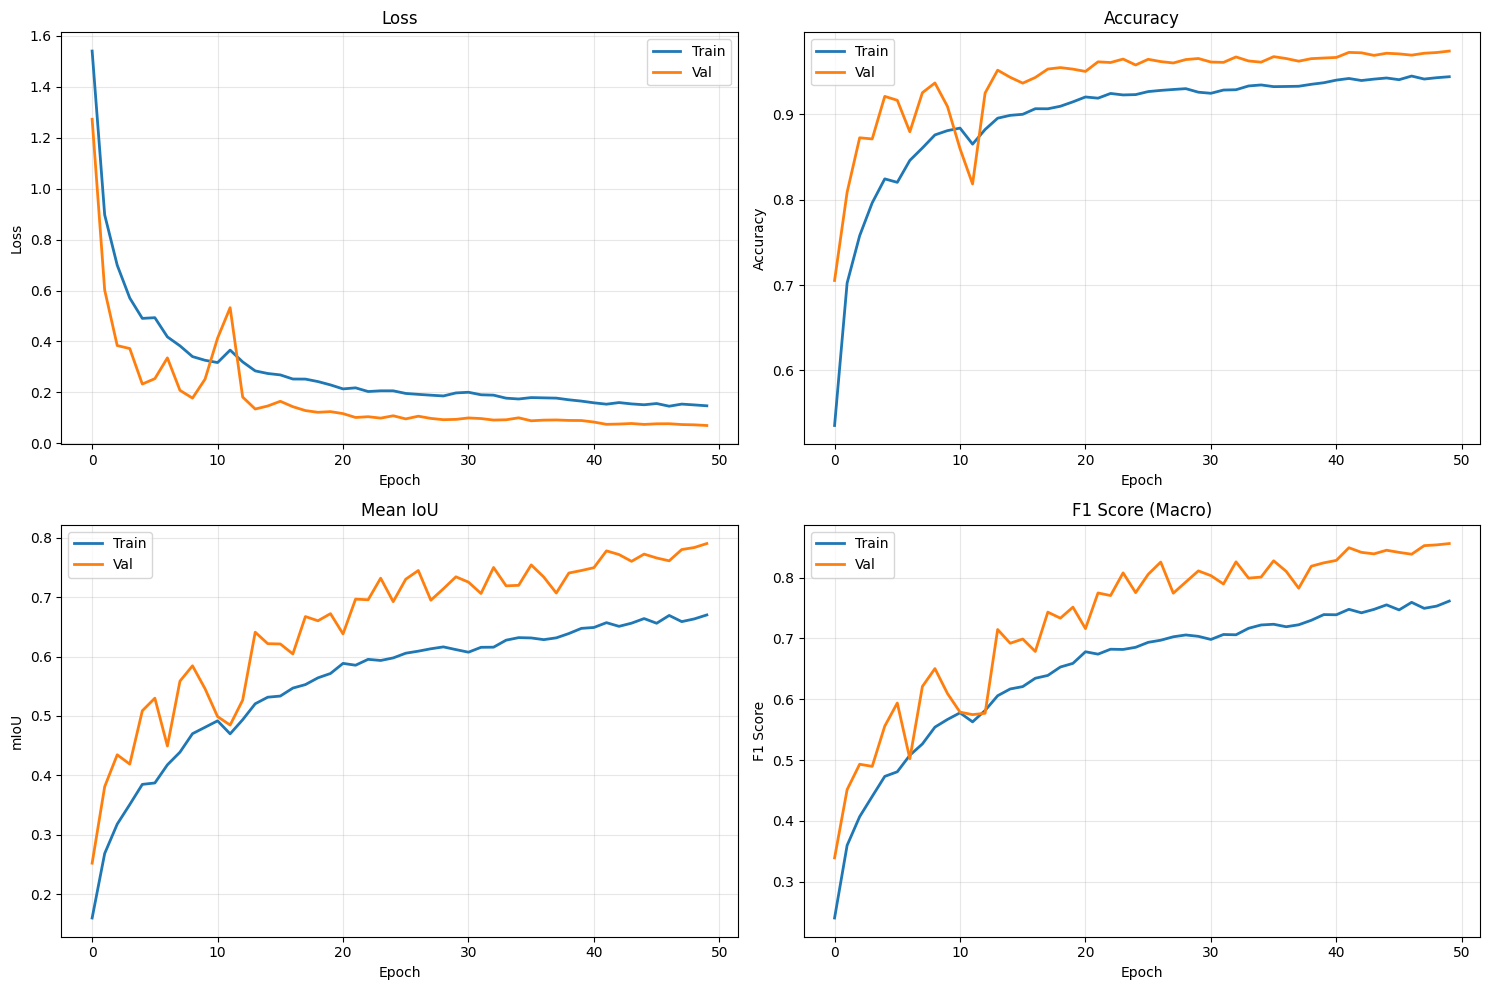


ТЕСТИРОВАНИЕ МОДЕЛИ
Загружена модель с epoch 50
Val mIoU: 0.7902, Val Acc: 0.9743


Testing: 100%|██████████| 10/10 [00:02<00:00,  3.82it/s]



РЕЗУЛЬТАТЫ НА ТЕСТОВОМ НАБОРЕ
Overall Accuracy: 0.9741
Mean IoU (mIoU): 0.7876
F1 Score (Macro): 0.8531
F1 Score (Weighted): 0.9731

Per-class IoU:
  Class 0: 0.9682
  Class 1: 0.1271
  Class 2: 0.4976
  Class 3: 0.7510
  Class 4: 0.7694
  Class 5: 0.9211
  Class 6: 0.8357
  Class 7: 0.9546
  Class 8: 0.4318
  Class 9: 0.5312
  Class 10: 0.9568
  Class 11: 0.9687
  Class 12: 0.9748
  Class 13: 0.9825
  Class 14: 0.9788
  Class 15: 0.9527

Per-class F1:
  Class 0: 0.9838
  Class 1: 0.2256
  Class 2: 0.6645
  Class 3: 0.8578
  Class 4: 0.8697
  Class 5: 0.9589
  Class 6: 0.9105
  Class 7: 0.9768
  Class 8: 0.6032
  Class 9: 0.6938
  Class 10: 0.9779
  Class 11: 0.9841
  Class 12: 0.9872
  Class 13: 0.9912
  Class 14: 0.9893
  Class 15: 0.9758


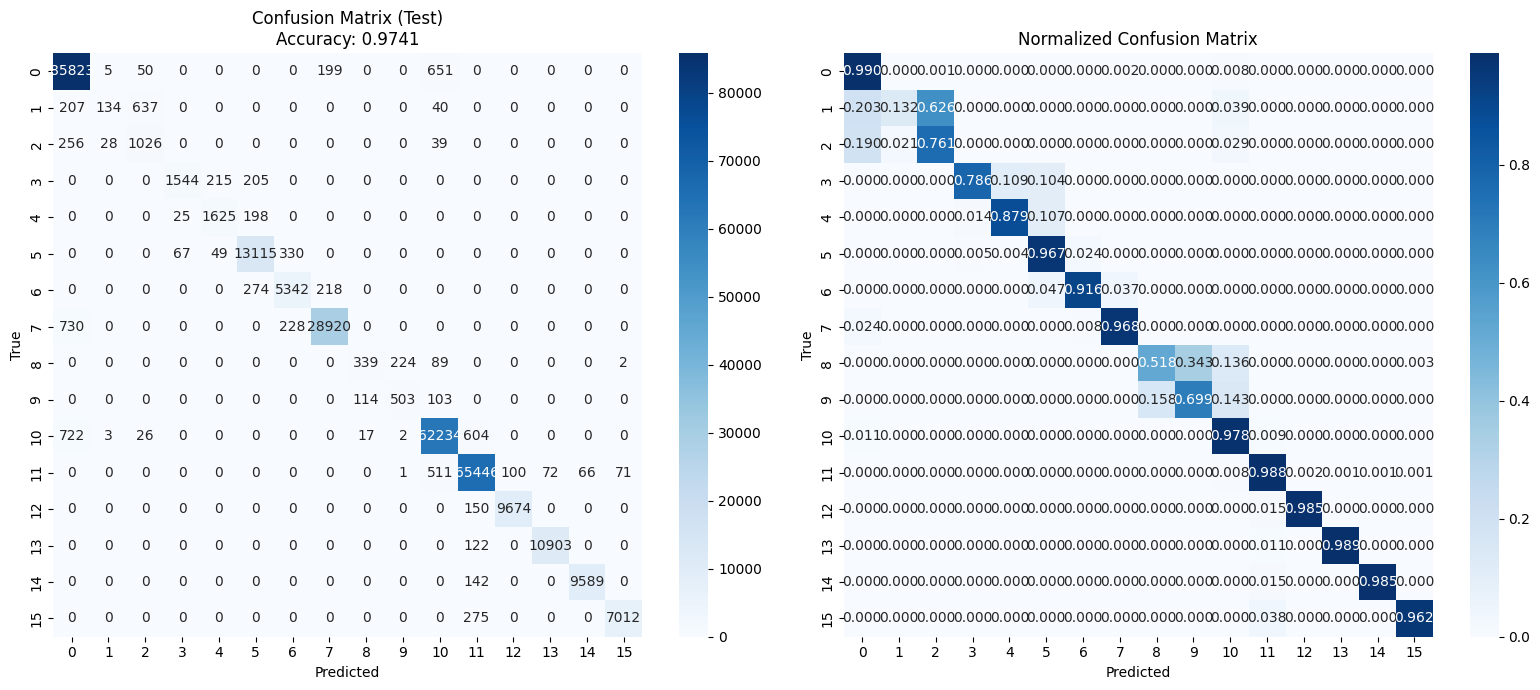


 Результаты сохранены:
  - Модель: /content/best_dgcnn_model.pth
  - Графики: /content/dgcnn_training_history.png
  - Матрица ошибок: /content/dgcnn_confusion_matrix.png
  - Результаты: /content/dgcnn_results.json


In [15]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from plyfile import PlyData
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, jaccard_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json

class FixedLiDARDataset(Dataset):
    def __init__(self, ply_files, num_points=4096, normalize=True, augment=False):
        self.ply_files = ply_files
        self.num_points = num_points
        self.normalize = normalize
        self.augment = augment

        # Загружаем данные
        self.data = []
        all_labels = set()

        for i, fpath in enumerate(ply_files):
            points, labels = self._load_ply(fpath)
            if points is not None:
                self.data.append((points, labels))
                all_labels.update(np.unique(labels))

        # Маппинг классов в последовательные (0, 1, 2, ...)
        self.old_to_new = {old: new for new, old in enumerate(sorted(all_labels))}
        self.num_classes = len(self.old_to_new)

        # Применяем маппинг
        self.mapped_data = []
        for points, labels in self.data:
            new_labels = np.array([self.old_to_new[l] for l in labels])
            self.mapped_data.append((points, new_labels))

    def _load_ply(self, filepath):
        try:
            with open(filepath, 'rb') as f:
                plydata = PlyData.read(f)

            x = plydata['vertex']['x'].astype(np.float32)
            y = plydata['vertex']['y'].astype(np.float32)
            z = plydata['vertex']['z'].astype(np.float32)
            points = np.stack([x, y, z], axis=1)

            # Пробуем разные имена поля с метками
            vertex_dtype = plydata['vertex'].data.dtype.names
            if 'scalar_Label' in vertex_dtype:
                labels = plydata['vertex']['scalar_Label'].astype(np.int64)
            elif 'scalar_label' in vertex_dtype:
                labels = plydata['vertex']['scalar_label'].astype(np.int64)
            else:
                return None, None

            return points, labels
        except:
            return None, None

    def __len__(self):
        return len(self.mapped_data)

    def __getitem__(self, idx):
        points, labels = self.mapped_data[idx]

        # Сэмплирование до фиксированного числа точек
        n_points = len(points)
        if n_points > self.num_points:
            indices = np.random.choice(n_points, self.num_points, replace=False)
        else:
            indices = np.random.choice(n_points, self.num_points, replace=True)

        points = points[indices]
        labels = labels[indices]

        # Нормализация
        if self.normalize:
            centroid = np.mean(points, axis=0)
            points = points - centroid
            max_dist = np.max(np.linalg.norm(points, axis=1))
            if max_dist > 0:
                points = points / max_dist

        # Аугментация (только для обучения)
        if self.augment:
            # Случайный поворот вокруг оси Z
            if np.random.random() > 0.5:
                theta = np.random.uniform(0, 2 * np.pi)
                rot = np.array([
                    [np.cos(theta), -np.sin(theta), 0],
                    [np.sin(theta), np.cos(theta), 0],
                    [0, 0, 1]
                ])
                points = points @ rot.T

            # Случайный шум
            if np.random.random() > 0.7:
                points += np.random.normal(0, 0.01, points.shape)

        # Преобразование в тензоры
        points = torch.tensor(points, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.long)

        # Транспонируем для DGCNN: (3, N)
        points = points.transpose(0, 1)

        return points, labels



def dgcnn_knn(x, k):
    """Поиск k ближайших соседей
    x: (B, C, N) -> idx: (B, N, k)
    """
    inner = -2 * torch.matmul(x.transpose(2, 1), x)
    xx = (x ** 2).sum(dim=1, keepdim=True)
    dist = -xx - inner - xx.transpose(2, 1)
    return dist.topk(k=k, dim=-1).indices


def get_graph_feature(x, k, idx=None):
    """Построение признаков графа
    x: (B, C, N) -> (B, 2C, N, k)
    """
    B, C, N = x.shape
    if idx is None:
        idx = dgcnn_knn(x, k)
    device = x.device
    idx_base = torch.arange(B, device=device).view(-1, 1, 1) * N
    idx = idx + idx_base
    idx = idx.view(-1)
    x_t = x.transpose(2, 1).contiguous()
    feat = x_t.view(B * N, -1)[idx, :].view(B, N, k, C)
    x_rep = x_t.view(B, N, 1, C).expand(-1, -1, k, -1)
    feat = torch.cat([feat - x_rep, x_rep], dim=-1).permute(0, 3, 1, 2).contiguous()
    return feat


class DGCNNSeg(nn.Module):
    """DGCNN для семантической сегментации"""
    def __init__(self, num_classes, k=20):
        super().__init__()
        self.k = k

        def edge_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c * 2, out_c, 1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2, inplace=True),
            )

        self.conv1 = edge_block(3, 64)
        self.conv2 = edge_block(64, 64)
        self.conv3 = edge_block(64, 64)

        self.conv4 = nn.Sequential(
            nn.Conv1d(64 * 3, 1024, 1, bias=False),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.seg = nn.Sequential(
            nn.Conv1d(1024 + 64 * 3, 256, 1, bias=False),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Conv1d(256, 256, 1, bias=False),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Conv1d(256, 128, 1, bias=False),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv1d(128, num_classes, 1),
        )

    def forward(self, x):
        # x: (B, 3, N)
        N = x.shape[2]

        x1 = self.conv1(get_graph_feature(x, self.k)).max(dim=-1)[0]
        x2 = self.conv2(get_graph_feature(x1, self.k)).max(dim=-1)[0]
        x3 = self.conv3(get_graph_feature(x2, self.k)).max(dim=-1)[0]

        cat = torch.cat([x1, x2, x3], dim=1)
        g = self.conv4(cat).max(dim=-1, keepdim=True)[0].repeat(1, 1, N)
        out = self.seg(torch.cat([cat, g], dim=1))

        return out.permute(0, 2, 1)  # (B, N, num_classes)



class MetricsCollector:
    """Сбор и вычисление метрик"""
    def __init__(self, num_classes):
        self.num_classes = num_classes

    def compute(self, preds, targets):
        """Вычисление всех метрик"""
        # Преобразуем в numpy массивы
        preds = np.array(preds)
        targets = np.array(targets)

        # Accuracy
        accuracy = accuracy_score(targets, preds)

        # Per-class IoU
        per_class_iou = {}
        for c in range(self.num_classes):
            intersection = ((preds == c) & (targets == c)).sum()
            union = ((preds == c) | (targets == c)).sum()
            iou = intersection / union if union > 0 else 0
            per_class_iou[c] = iou

        # Mean IoU
        mean_iou = np.mean(list(per_class_iou.values()))

        # F1 scores
        f1_macro = f1_score(targets, preds, average='macro', zero_division=0)
        f1_weighted = f1_score(targets, preds, average='weighted', zero_division=0)

        # Per-class F1
        per_class_f1 = f1_score(targets, preds, average=None, zero_division=0)
        if len(per_class_f1) < self.num_classes:
            per_class_f1_full = np.zeros(self.num_classes)
            for i, val in enumerate(per_class_f1):
                per_class_f1_full[i] = val
            per_class_f1 = per_class_f1_full

        return {
            'accuracy': accuracy,
            'mean_iou': mean_iou,
            'f1_macro': f1_macro,
            'f1_weighted': f1_weighted,
            'per_class_iou': per_class_iou,
            'per_class_f1': per_class_f1
        }


def train_epoch(model, loader, optimizer, criterion, device):
    """Одна эпоха обучения"""
    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []

    pbar = tqdm(loader, desc="Training")
    for points, labels in pbar:
        points, labels = points.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(points)
        loss = criterion(outputs.transpose(1, 2), labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=2)
        all_preds.extend(preds.cpu().numpy().flatten())
        all_targets.extend(labels.cpu().numpy().flatten())

        pbar.set_postfix({'loss': loss.item()})

    return total_loss / len(loader), all_preds, all_targets


def validate_epoch(model, loader, criterion, device):
    """Валидация"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Validation")
        for points, labels in pbar:
            points, labels = points.to(device), labels.to(device)

            outputs = model(points)
            loss = criterion(outputs.transpose(1, 2), labels)

            total_loss += loss.item()

            preds = outputs.argmax(dim=2)
            all_preds.extend(preds.cpu().numpy().flatten())
            all_targets.extend(labels.cpu().numpy().flatten())

    return total_loss / len(loader), all_preds, all_targets



def main():
    # Параметры
    NUM_POINTS = 4096
    BATCH_SIZE = 8
    NUM_EPOCHS = 50
    LEARNING_RATE = 0.001
    K_NEIGHBORS = 20
    WEIGHT_DECAY = 1e-4

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Используется устройство: {device}")
    if device.type == 'cuda':
        print(f"GPU: {torch.cuda.get_device_name(0)}")


    print("\n" + "="*60)
    print("ЗАГРУЗКА ДАННЫХ")
    print("="*60)

    # Поиск всех PLY файлов
    EXTRACT_PATH = '/content/dataset'
    ply_files = []
    for root, dirs, files in os.walk(EXTRACT_PATH):
        for file in files:
            if file.endswith('.ply'):
                ply_files.append(os.path.join(root, file))

    print(f"Найдено PLY файлов: {len(ply_files)}")

    if len(ply_files) == 0:
        print("❌ Ошибка: PLY файлы не найдены!")
        return

    # Разбиение на train/val/test (70/15/15)
    train_files, temp_files = train_test_split(ply_files, test_size=0.3, random_state=42)
    val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

    print(f"\nРазбиение:")
    print(f"  Train: {len(train_files)} объектов")
    print(f"  Val:   {len(val_files)} объектов")
    print(f"  Test:  {len(test_files)} объектов")

   
    print("\nСоздание датасетов...")
    train_dataset = FixedLiDARDataset(train_files, num_points=NUM_POINTS, normalize=True, augment=True)
    val_dataset = FixedLiDARDataset(val_files, num_points=NUM_POINTS, normalize=True, augment=False)
    test_dataset = FixedLiDARDataset(test_files, num_points=NUM_POINTS, normalize=True, augment=False)

    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    num_classes = train_dataset.num_classes
    print(f"\n✅ Количество классов: {num_classes}")


    print("\n" + "="*60)
    print("СОЗДАНИЕ МОДЕЛИ")
    print("="*60)

    model = DGCNNSeg(num_classes=num_classes, k=K_NEIGHBORS).to(device)
    print(f"Модель: DGCNN")
    print(f"Количество параметров: {sum(p.numel() for p in model.parameters()):,}")
    print(f"K neighbors: {K_NEIGHBORS}")


    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

    metrics_collector = MetricsCollector(num_classes)

   
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_miou': [], 'val_miou': [],
        'train_f1': [], 'val_f1': []
    }

    best_val_miou = 0
    best_epoch = 0
    model_path = '/content/best_dgcnn_model.pth'

    print(f"\nПараметры обучения:")
    print(f"  Epochs: {NUM_EPOCHS}")
    print(f"  Batch size: {BATCH_SIZE}")
    print(f"  Learning rate: {LEARNING_RATE}")


    print("\n" + "="*60)
    print("НАЧАЛО ОБУЧЕНИЯ")
    print("="*60)

    start_time = time.time()

    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-"*40)

        # Обучение
        train_loss, train_preds, train_targets = train_epoch(
            model, train_loader, optimizer, criterion, device
        )
        train_metrics = metrics_collector.compute(train_preds, train_targets)

        # Валидация
        val_loss, val_preds, val_targets = validate_epoch(
            model, val_loader, criterion, device
        )
        val_metrics = metrics_collector.compute(val_preds, val_targets)

       
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_metrics['accuracy'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['train_miou'].append(train_metrics['mean_iou'])
        history['val_miou'].append(val_metrics['mean_iou'])
        history['train_f1'].append(train_metrics['f1_macro'])
        history['val_f1'].append(val_metrics['f1_macro'])

        # Вывод результатов
        print(f"Train - Loss: {train_loss:.4f}, Acc: {train_metrics['accuracy']:.4f}, "
              f"mIoU: {train_metrics['mean_iou']:.4f}, F1: {train_metrics['f1_macro']:.4f}")
        print(f"Val   - Loss: {val_loss:.4f}, Acc: {val_metrics['accuracy']:.4f}, "
              f"mIoU: {val_metrics['mean_iou']:.4f}, F1: {val_metrics['f1_macro']:.4f}")

        # Сохранение лучшей модели по mIoU
        if val_metrics['mean_iou'] > best_val_miou:
            best_val_miou = val_metrics['mean_iou']
            best_epoch = epoch + 1
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_miou': val_metrics['mean_iou'],
                'val_acc': val_metrics['accuracy'],
                'num_classes': num_classes
            }, model_path)
            print(f"  ✓ Сохранена лучшая модель (mIoU: {best_val_miou:.4f})")

        # Обновление learning rate
        scheduler.step()

    training_time = time.time() - start_time
    print(f"\n✅ Обучение завершено за {training_time/60:.1f} минут")
    print(f"Лучшая mIoU на валидации: {best_val_miou:.4f} (epoch {best_epoch})")

    print("\n" + "="*60)
    print("ВИЗУАЛИЗАЦИЯ")
    print("="*60)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Loss
    axes[0, 0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0, 0].plot(history['val_loss'], label='Val', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Accuracy
    axes[0, 1].plot(history['train_acc'], label='Train', linewidth=2)
    axes[0, 1].plot(history['val_acc'], label='Val', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # mIoU
    axes[1, 0].plot(history['train_miou'], label='Train', linewidth=2)
    axes[1, 0].plot(history['val_miou'], label='Val', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('mIoU')
    axes[1, 0].set_title('Mean IoU')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # F1
    axes[1, 1].plot(history['train_f1'], label='Train', linewidth=2)
    axes[1, 1].plot(history['val_f1'], label='Val', linewidth=2)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('F1 Score')
    axes[1, 1].set_title('F1 Score (Macro)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/dgcnn_training_history.png', dpi=150)
    plt.show()


    print("\n" + "="*60)
    print("ТЕСТИРОВАНИЕ МОДЕЛИ")
    print("="*60)

    # Загрузка лучшей модели
    checkpoint = torch.load(model_path, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Загружена модель с epoch {checkpoint['epoch']+1}")
    print(f"Val mIoU: {checkpoint['val_miou']:.4f}, Val Acc: {checkpoint['val_acc']:.4f}")

    # Тестирование
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(test_loader, desc="Testing")
        for points, labels in pbar:
            points = points.to(device)
            outputs = model(points)
            preds = outputs.argmax(dim=2)
            all_preds.extend(preds.cpu().numpy().flatten())
            all_targets.extend(labels.numpy().flatten())

    # Метрики на тесте
    test_metrics = metrics_collector.compute(all_preds, all_targets)

    print("\n" + "="*60)
    print("РЕЗУЛЬТАТЫ НА ТЕСТОВОМ НАБОРЕ")
    print("="*60)
    print(f"Overall Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"Mean IoU (mIoU): {test_metrics['mean_iou']:.4f}")
    print(f"F1 Score (Macro): {test_metrics['f1_macro']:.4f}")
    print(f"F1 Score (Weighted): {test_metrics['f1_weighted']:.4f}")

    print("\nPer-class IoU:")
    for c in range(num_classes):
        print(f"  Class {c}: {test_metrics['per_class_iou'][c]:.4f}")

    print("\nPer-class F1:")
    for c in range(num_classes):
        print(f"  Class {c}: {test_metrics['per_class_f1'][c]:.4f}")


    cm = confusion_matrix(all_targets, all_preds, labels=range(num_classes))

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Абсолютная матрица
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(num_classes), yticklabels=range(num_classes),
                ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title(f'Confusion Matrix (Test)\nAccuracy: {test_metrics["accuracy"]:.4f}')

    # Нормализованная матрица
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.nan_to_num(cm_norm, nan=0)

    sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
                xticklabels=range(num_classes), yticklabels=range(num_classes),
                ax=axes[1])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    axes[1].set_title('Normalized Confusion Matrix')

    plt.tight_layout()
    plt.savefig('/content/dgcnn_confusion_matrix.png', dpi=150)
    plt.show()


    results = {
        'model': 'DGCNN',
        'num_classes': num_classes,
        'num_points': NUM_POINTS,
        'k_neighbors': K_NEIGHBORS,
        'batch_size': BATCH_SIZE,
        'num_epochs': NUM_EPOCHS,
        'best_val_miou': best_val_miou,
        'best_epoch': best_epoch,
        'test_metrics': {
            'accuracy': float(test_metrics['accuracy']),
            'mean_iou': float(test_metrics['mean_iou']),
            'f1_macro': float(test_metrics['f1_macro']),
            'f1_weighted': float(test_metrics['f1_weighted']),
            'per_class_iou': {int(k): float(v) for k, v in test_metrics['per_class_iou'].items()},
            'per_class_f1': {int(k): float(v) for k, v in enumerate(test_metrics['per_class_f1'])}
        },
        'training_time': training_time
    }

    with open('/content/dgcnn_results.json', 'w') as f:
        json.dump(results, f, indent=2)

    print("\n Результаты сохранены:")
    print("  - Модель: /content/best_dgcnn_model.pth")
    print("  - Графики: /content/dgcnn_training_history.png")
    print("  - Матрица ошибок: /content/dgcnn_confusion_matrix.png")
    print("  - Результаты: /content/dgcnn_results.json")

    return results



if __name__ == "__main__":
    results = main()

Используется устройство: cuda
GPU: Tesla T4

ЗАГРУЗКА ДАННЫХ
Найдено PLY файлов: 503

Разбиение:
  Train: 352 объектов
  Val:   75 объектов
  Test:  76 объектов

СОЗДАНИЕ МОДЕЛИ
Модель: PointNet++
Количество параметров: 265,296

Параметры обучения:
  Epochs: 50
  Batch size: 8
  Learning rate: 0.001

НАЧАЛО ОБУЧЕНИЯ

Epoch 1/50
----------------------------------------


Validation: 100%|██████████| 10/10 [00:01<00:00,  8.65it/s]


Train - Loss: 1.2849, Acc: 0.6318, mIoU: 0.2207, F1: 0.3110
Val   - Loss: 2.5783, Acc: 0.2169, mIoU: 0.0136, F1: 0.0224
  ✓ Сохранена лучшая модель (mIoU: 0.0136)

Epoch 2/50
----------------------------------------


Validation: 100%|██████████| 10/10 [00:01<00:00,  8.61it/s]


Train - Loss: 0.5937, Acc: 0.7989, mIoU: 0.3723, F1: 0.4624
Val   - Loss: 1.3967, Acc: 0.5373, mIoU: 0.1637, F1: 0.2456
  ✓ Сохранена лучшая модель (mIoU: 0.1637)

Epoch 3/50
----------------------------------------


...

Train - Loss: 0.1174, Acc: 0.9551, mIoU: 0.8263, F1: 0.8997
Val   - Loss: 0.0653, Acc: 0.9745, mIoU: 0.9127, F1: 0.9534

Epoch 49/50
----------------------------------------


Validation: 100%|██████████| 10/10 [00:01<00:00,  7.60it/s]


Train - Loss: 0.1148, Acc: 0.9563, mIoU: 0.8328, F1: 0.9045
Val   - Loss: 0.0658, Acc: 0.9740, mIoU: 0.9067, F1: 0.9499

Epoch 50/50
----------------------------------------


Validation: 100%|██████████| 10/10 [00:01<00:00,  8.68it/s]


Train - Loss: 0.1194, Acc: 0.9540, mIoU: 0.8300, F1: 0.9027
Val   - Loss: 0.0634, Acc: 0.9755, mIoU: 0.9122, F1: 0.9530

✅ Обучение завершено за 6.8 минут
Лучшая mIoU на валидации: 0.9160 (epoch 44)

ВИЗУАЛИЗАЦИЯ


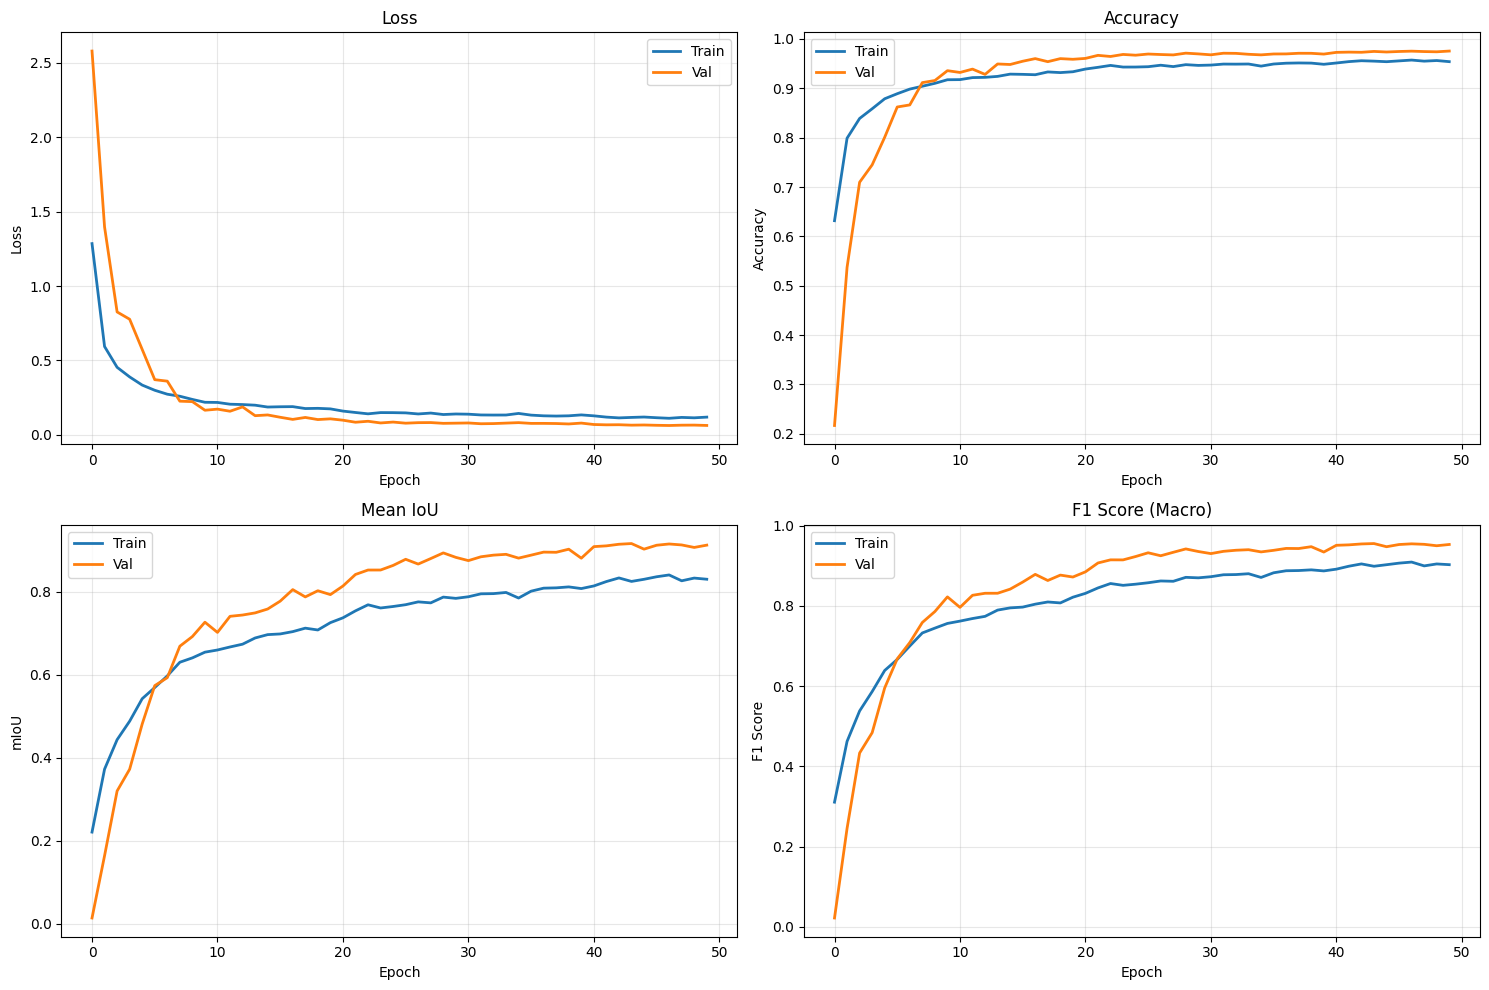


ТЕСТИРОВАНИЕ МОДЕЛИ
Загружена модель с epoch 44
Val mIoU: 0.9160, Val Acc: 0.9748


Testing: 100%|██████████| 10/10 [00:01<00:00,  8.57it/s]



РЕЗУЛЬТАТЫ НА ТЕСТОВОМ НАБОРЕ
Overall Accuracy: 0.9735
Mean IoU (mIoU): 0.9164
F1 Score (Macro): 0.9555
F1 Score (Weighted): 0.9735

Per-class IoU:
  Class 0: 0.9558
  Class 1: 0.8610
  Class 2: 0.8703
  Class 3: 0.8805
  Class 4: 0.9300
  Class 5: 0.9101
  Class 6: 0.7921
  Class 7: 0.9394
  Class 8: 0.8417
  Class 9: 0.8662
  Class 10: 0.9378
  Class 11: 0.9666
  Class 12: 0.9783
  Class 13: 0.9827
  Class 14: 0.9807
  Class 15: 0.9696

Per-class F1:
  Class 0: 0.9774
  Class 1: 0.9253
  Class 2: 0.9306
  Class 3: 0.9365
  Class 4: 0.9637
  Class 5: 0.9529
  Class 6: 0.8840
  Class 7: 0.9688
  Class 8: 0.9141
  Class 9: 0.9283
  Class 10: 0.9679
  Class 11: 0.9830
  Class 12: 0.9890
  Class 13: 0.9913
  Class 14: 0.9902
  Class 15: 0.9846


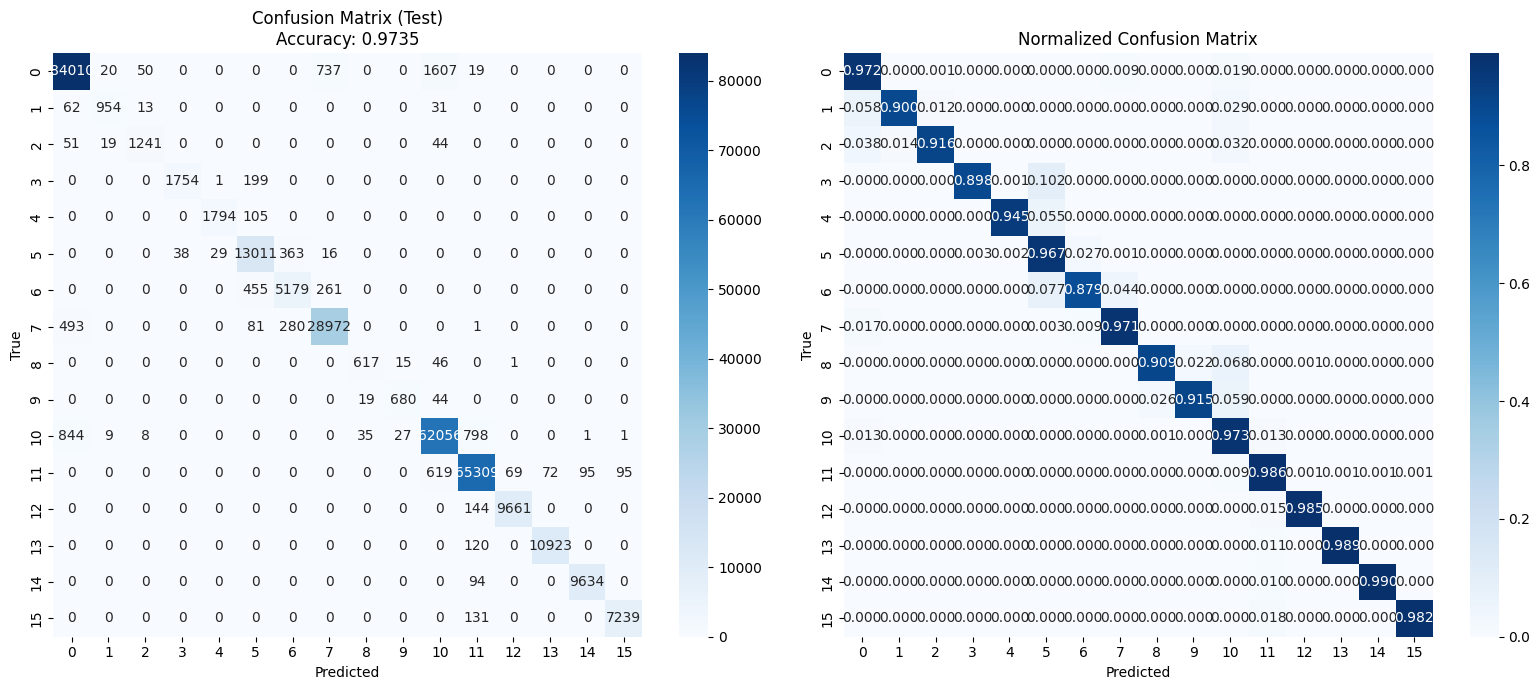

In [17]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, jaccard_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json


def square_dist(a, b):
    # a: (B, N, 3), b: (B, M, 3) -> (B, N, M)
    return torch.cdist(a, b, p=2) ** 2

def gather_points(points, idx):
    # points: (B, N, C), idx: (B, S) -> (B, S, C)
    B, N, C = points.shape
    S = idx.shape[1]
    batch_idx = torch.arange(B, device=points.device).view(B, 1).expand(B, S)
    return points[batch_idx, idx]

def gather_groups(points, idx):
    # points: (B, N, C), idx: (B, S, K) -> (B, S, K, C)
    B, N, C = points.shape
    S, K = idx.shape[1], idx.shape[2]
    batch_idx = torch.arange(B, device=points.device).view(B, 1, 1).expand(B, S, K)
    return points[batch_idx, idx]

def farthest_point_sample(xyz, npoint):
    # xyz: (B, N, 3) -> centroid_idx (B, npoint)
    B, N, _ = xyz.shape
    device = xyz.device
    centroids = torch.zeros(B, npoint, dtype=torch.long, device=device)
    distance = torch.full((B, N), 1e10, device=device)
    farthest = torch.randint(0, N, (B,), device=device, dtype=torch.long)
    batch_indices = torch.arange(B, device=device, dtype=torch.long)
    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = xyz[batch_indices, farthest, :].view(B, 1, 3)
        dist = ((xyz - centroid) ** 2).sum(-1)
        distance = torch.minimum(distance, dist)
        farthest = torch.max(distance, dim=-1)[1]
    return centroids

def knn_idx(query, key, k):
    # query: (B, S, 3), key: (B, N, 3) -> (B, S, k)
    d = square_dist(query, key)
    return d.topk(k=k, dim=-1, largest=False).indices

def three_nn_interp(target_xyz, source_xyz, source_feat):
    # target_xyz: (B, N, 3); source_xyz: (B, S, 3); source_feat: (B, S, C)
    d = square_dist(target_xyz, source_xyz)            # (B, N, S)
    d_topk, idx_topk = d.topk(k=3, dim=-1, largest=False)  # (B, N, 3)
    d_topk = torch.clamp(d_topk, min=1e-10)
    weight = 1.0 / d_topk
    weight = weight / weight.sum(dim=-1, keepdim=True) # (B, N, 3)
    neigh_feat = gather_groups(source_feat, idx_topk)  # (B, N, 3, C)
    interp = (neigh_feat * weight.unsqueeze(-1)).sum(dim=2)  # (B, N, C)
    return interp


class SetAbstraction(nn.Module):
    '''FPS -> kNN grouping -> shared MLP -> max pool.'''
    def __init__(self, npoint, k, in_ch, mlp_channels):
        super().__init__()
        self.npoint = npoint
        self.k = k
        layers = []
        c_prev = in_ch + 3  # конкат с relative xyz
        for c in mlp_channels:
            layers += [nn.Conv2d(c_prev, c, 1), nn.BatchNorm2d(c), nn.ReLU(inplace=True)]
            c_prev = c
        self.mlp = nn.Sequential(*layers)

    def forward(self, xyz, feat):
        # xyz: (B, N, 3); feat: (B, N, C) или None
        B, N, _ = xyz.shape
        fps_idx = farthest_point_sample(xyz, self.npoint)        # (B, npoint)
        new_xyz = gather_points(xyz, fps_idx)                    # (B, npoint, 3)
        knn = knn_idx(new_xyz, xyz, self.k)                      # (B, npoint, k)
        grouped_xyz = gather_groups(xyz, knn)                    # (B, npoint, k, 3)
        grouped_xyz_rel = grouped_xyz - new_xyz.unsqueeze(2)
        if feat is not None:
            grouped_feat = gather_groups(feat, knn)              # (B, npoint, k, C)
            grouped = torch.cat([grouped_xyz_rel, grouped_feat], dim=-1)
        else:
            grouped = grouped_xyz_rel
        # (B, npoint, k, C+3) -> (B, C+3, npoint, k)
        grouped = grouped.permute(0, 3, 1, 2)
        new_feat = self.mlp(grouped)                              # (B, C', npoint, k)
        new_feat = new_feat.max(dim=-1)[0]                        # (B, C', npoint)
        new_feat = new_feat.permute(0, 2, 1)                      # (B, npoint, C')
        return new_xyz, new_feat


class FeaturePropagation(nn.Module):
    def __init__(self, in_ch, mlp_channels):
        super().__init__()
        layers = []
        c_prev = in_ch
        for c in mlp_channels:
            layers += [nn.Conv1d(c_prev, c, 1), nn.BatchNorm1d(c), nn.ReLU(inplace=True)]
            c_prev = c
        self.mlp = nn.Sequential(*layers)

    def forward(self, target_xyz, source_xyz, target_feat, source_feat):
        interp = three_nn_interp(target_xyz, source_xyz, source_feat)  # (B, N, Cs)
        if target_feat is not None:
            new_feat = torch.cat([interp, target_feat], dim=-1)        # (B, N, Cs+Ct)
        else:
            new_feat = interp
        new_feat = new_feat.permute(0, 2, 1)                            # (B, C, N)
        return self.mlp(new_feat).permute(0, 2, 1)                      # (B, N, C')


class PointNetPlusPlusSeg(nn.Module):
    '''Упрощённая PointNet++ (SSG) для сегментации.'''
    def __init__(self, num_classes):
        super().__init__()
        self.sa1 = SetAbstraction(npoint=512, k=32, in_ch=0,  mlp_channels=[64, 64, 128])
        self.sa2 = SetAbstraction(npoint=128, k=32, in_ch=128, mlp_channels=[128, 128, 256])
        self.fp2 = FeaturePropagation(in_ch=256 + 128, mlp_channels=[256, 128])
        self.fp1 = FeaturePropagation(in_ch=128, mlp_channels=[128, 128])
        self.head = nn.Sequential(
            nn.Conv1d(128, 128, 1), nn.BatchNorm1d(128), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Conv1d(128, num_classes, 1),
        )

    def forward(self, x):
        # x: (B, 3, N) -> приводим к (B, N, 3)
        xyz0 = x.permute(0, 2, 1).contiguous()
        xyz1, feat1 = self.sa1(xyz0, None)
        xyz2, feat2 = self.sa2(xyz1, feat1)
        # FP назад
        feat1_up = self.fp2(xyz1, xyz2, feat1, feat2)
        feat0_up = self.fp1(xyz0, xyz1, None, feat1_up)
        # (B, N, C) -> (B, C, N) для свёртки
        out = self.head(feat0_up.permute(0, 2, 1))
        return out



class FixedLiDARDataset(Dataset):
    def __init__(self, ply_files, num_points=4096, normalize=True, augment=False):
        self.ply_files = ply_files
        self.num_points = num_points
        self.normalize = normalize
        self.augment = augment

        # Загружаем данные
        self.data = []
        all_labels = set()

        for i, fpath in enumerate(ply_files):
            points, labels = self._load_ply(fpath)
            if points is not None:
                self.data.append((points, labels))
                all_labels.update(np.unique(labels))

        # Маппинг классов
        self.old_to_new = {old: new for new, old in enumerate(sorted(all_labels))}
        self.num_classes = len(self.old_to_new)

        # Применяем маппинг
        self.mapped_data = []
        for points, labels in self.data:
            new_labels = np.array([self.old_to_new[l] for l in labels])
            self.mapped_data.append((points, new_labels))

    def _load_ply(self, filepath):
        try:
            with open(filepath, 'rb') as f:
                plydata = PlyData.read(f)

            x = plydata['vertex']['x'].astype(np.float32)
            y = plydata['vertex']['y'].astype(np.float32)
            z = plydata['vertex']['z'].astype(np.float32)
            points = np.stack([x, y, z], axis=1)

            vertex_dtype = plydata['vertex'].data.dtype.names
            if 'scalar_Label' in vertex_dtype:
                labels = plydata['vertex']['scalar_Label'].astype(np.int64)
            elif 'scalar_label' in vertex_dtype:
                labels = plydata['vertex']['scalar_label'].astype(np.int64)
            else:
                return None, None

            return points, labels
        except:
            return None, None

    def __len__(self):
        return len(self.mapped_data)

    def __getitem__(self, idx):
        points, labels = self.mapped_data[idx]

        # Сэмплирование
        n_points = len(points)
        if n_points > self.num_points:
            indices = np.random.choice(n_points, self.num_points, replace=False)
        else:
            indices = np.random.choice(n_points, self.num_points, replace=True)

        points = points[indices]
        labels = labels[indices]

        # Нормализация
        if self.normalize:
            centroid = np.mean(points, axis=0)
            points = points - centroid
            max_dist = np.max(np.linalg.norm(points, axis=1))
            if max_dist > 0:
                points = points / max_dist

        # Аугментация
        if self.augment:
            if np.random.random() > 0.5:
                theta = np.random.uniform(0, 2 * np.pi)
                rot = np.array([
                    [np.cos(theta), -np.sin(theta), 0],
                    [np.sin(theta), np.cos(theta), 0],
                    [0, 0, 1]
                ])
                points = points @ rot.T
            if np.random.random() > 0.7:
                points += np.random.normal(0, 0.01, points.shape)

        points = torch.tensor(points, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.long)

        # Для PointNet++ вход: (3, N)
        points = points.transpose(0, 1)

        return points, labels



class MetricsCollector:
    def __init__(self, num_classes):
        self.num_classes = num_classes

    def compute(self, preds, targets):
        preds = np.array(preds)
        targets = np.array(targets)

        accuracy = accuracy_score(targets, preds)

        per_class_iou = {}
        for c in range(self.num_classes):
            intersection = ((preds == c) & (targets == c)).sum()
            union = ((preds == c) | (targets == c)).sum()
            iou = intersection / union if union > 0 else 0
            per_class_iou[c] = iou

        mean_iou = np.mean(list(per_class_iou.values()))

        f1_macro = f1_score(targets, preds, average='macro', zero_division=0)
        f1_weighted = f1_score(targets, preds, average='weighted', zero_division=0)

        per_class_f1 = f1_score(targets, preds, average=None, zero_division=0)
        if len(per_class_f1) < self.num_classes:
            per_class_f1_full = np.zeros(self.num_classes)
            for i, val in enumerate(per_class_f1):
                per_class_f1_full[i] = val
            per_class_f1 = per_class_f1_full

        return {
            'accuracy': accuracy,
            'mean_iou': mean_iou,
            'f1_macro': f1_macro,
            'f1_weighted': f1_weighted,
            'per_class_iou': per_class_iou,
            'per_class_f1': per_class_f1
        }


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_targets = []

    pbar = tqdm(loader, desc="Training")
    for points, labels in pbar:
        points, labels = points.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(points)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy().flatten())
        all_targets.extend(labels.cpu().numpy().flatten())

        pbar.set_postfix({'loss': loss.item()})

    return total_loss / len(loader), all_preds, all_targets


def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Validation")
        for points, labels in pbar:
            points, labels = points.to(device), labels.to(device)

            outputs = model(points)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy().flatten())
            all_targets.extend(labels.cpu().numpy().flatten())

    return total_loss / len(loader), all_preds, all_targets



def main():
    # Параметры
    NUM_POINTS = 4096
    BATCH_SIZE = 8
    NUM_EPOCHS = 50
    LEARNING_RATE = 0.001
    WEIGHT_DECAY = 1e-4

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Используется устройство: {device}")
    if device.type == 'cuda':
        print(f"GPU: {torch.cuda.get_device_name(0)}")


    print("\n" + "="*60)
    print("ЗАГРУЗКА ДАННЫХ")
    print("="*60)

    EXTRACT_PATH = '/content/dataset'
    ply_files = []
    for root, dirs, files in os.walk(EXTRACT_PATH):
        for file in files:
            if file.endswith('.ply'):
                ply_files.append(os.path.join(root, file))

    print(f"Найдено PLY файлов: {len(ply_files)}")

    if len(ply_files) == 0:
        print("❌ Ошибка: PLY файлы не найдены!")
        return

    train_files, temp_files = train_test_split(ply_files, test_size=0.3, random_state=42)
    val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

    print(f"\nРазбиение:")
    print(f"  Train: {len(train_files)} объектов")
    print(f"  Val:   {len(val_files)} объектов")
    print(f"  Test:  {len(test_files)} объектов")


    train_dataset = FixedLiDARDataset(train_files, num_points=NUM_POINTS, normalize=True, augment=True)
    val_dataset = FixedLiDARDataset(val_files, num_points=NUM_POINTS, normalize=True, augment=False)
    test_dataset = FixedLiDARDataset(test_files, num_points=NUM_POINTS, normalize=True, augment=False)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    num_classes = train_dataset.num_classes


    print("\n" + "="*60)
    print("СОЗДАНИЕ МОДЕЛИ")
    print("="*60)

    model = PointNetPlusPlusSeg(num_classes=num_classes).to(device)
    print(f"Модель: PointNet++")
    print(f"Количество параметров: {sum(p.numel() for p in model.parameters()):,}")

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

    metrics_collector = MetricsCollector(num_classes)

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_miou': [], 'val_miou': [],
        'train_f1': [], 'val_f1': []
    }

    best_val_miou = 0
    best_epoch = 0
    model_path = '/content/best_pointnetplusplus_model.pth'

    print(f"\nПараметры обучения:")
    print(f"  Epochs: {NUM_EPOCHS}")
    print(f"  Batch size: {BATCH_SIZE}")
    print(f"  Learning rate: {LEARNING_RATE}")

    print("\n" + "="*60)
    print("НАЧАЛО ОБУЧЕНИЯ")
    print("="*60)

    start_time = time.time()

    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-"*40)

        train_loss, train_preds, train_targets = train_epoch(
            model, train_loader, optimizer, criterion, device
        )
        train_metrics = metrics_collector.compute(train_preds, train_targets)

        val_loss, val_preds, val_targets = validate_epoch(
            model, val_loader, criterion, device
        )
        val_metrics = metrics_collector.compute(val_preds, val_targets)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_metrics['accuracy'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['train_miou'].append(train_metrics['mean_iou'])
        history['val_miou'].append(val_metrics['mean_iou'])
        history['train_f1'].append(train_metrics['f1_macro'])
        history['val_f1'].append(val_metrics['f1_macro'])

        print(f"Train - Loss: {train_loss:.4f}, Acc: {train_metrics['accuracy']:.4f}, "
              f"mIoU: {train_metrics['mean_iou']:.4f}, F1: {train_metrics['f1_macro']:.4f}")
        print(f"Val   - Loss: {val_loss:.4f}, Acc: {val_metrics['accuracy']:.4f}, "
              f"mIoU: {val_metrics['mean_iou']:.4f}, F1: {val_metrics['f1_macro']:.4f}")

        if val_metrics['mean_iou'] > best_val_miou:
            best_val_miou = val_metrics['mean_iou']
            best_epoch = epoch + 1
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_miou': val_metrics['mean_iou'],
                'val_acc': val_metrics['accuracy'],
                'num_classes': num_classes
            }, model_path)
            print(f"  ✓ Сохранена лучшая модель (mIoU: {best_val_miou:.4f})")

        scheduler.step()

    training_time = time.time() - start_time
    print(f"\n✅ Обучение завершено за {training_time/60:.1f} минут")
    print(f"Лучшая mIoU на валидации: {best_val_miou:.4f} (epoch {best_epoch})")


    print("\n" + "="*60)
    print("ВИЗУАЛИЗАЦИЯ")
    print("="*60)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    axes[0, 0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0, 0].plot(history['val_loss'], label='Val', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(history['train_acc'], label='Train', linewidth=2)
    axes[0, 1].plot(history['val_acc'], label='Val', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(history['train_miou'], label='Train', linewidth=2)
    axes[1, 0].plot(history['val_miou'], label='Val', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('mIoU')
    axes[1, 0].set_title('Mean IoU')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].plot(history['train_f1'], label='Train', linewidth=2)
    axes[1, 1].plot(history['val_f1'], label='Val', linewidth=2)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('F1 Score')
    axes[1, 1].set_title('F1 Score (Macro)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/pointnetplusplus_training_history.png', dpi=150)
    plt.show()


    print("\n" + "="*60)
    print("ТЕСТИРОВАНИЕ МОДЕЛИ")
    print("="*60)

    checkpoint = torch.load(model_path, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Загружена модель с epoch {checkpoint['epoch']+1}")
    print(f"Val mIoU: {checkpoint['val_miou']:.4f}, Val Acc: {checkpoint['val_acc']:.4f}")

    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(test_loader, desc="Testing")
        for points, labels in pbar:
            points = points.to(device)
            outputs = model(points)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy().flatten())
            all_targets.extend(labels.numpy().flatten())

    test_metrics = metrics_collector.compute(all_preds, all_targets)

    print("\n" + "="*60)
    print("РЕЗУЛЬТАТЫ НА ТЕСТОВОМ НАБОРЕ")
    print("="*60)
    print(f"Overall Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"Mean IoU (mIoU): {test_metrics['mean_iou']:.4f}")
    print(f"F1 Score (Macro): {test_metrics['f1_macro']:.4f}")
    print(f"F1 Score (Weighted): {test_metrics['f1_weighted']:.4f}")

    print("\nPer-class IoU:")
    for c in range(num_classes):
        print(f"  Class {c}: {test_metrics['per_class_iou'][c]:.4f}")

    print("\nPer-class F1:")
    for c in range(num_classes):
        print(f"  Class {c}: {test_metrics['per_class_f1'][c]:.4f}")

    cm = confusion_matrix(all_targets, all_preds, labels=range(num_classes))

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(num_classes), yticklabels=range(num_classes),
                ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title(f'Confusion Matrix (Test)\nAccuracy: {test_metrics["accuracy"]:.4f}')

    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.nan_to_num(cm_norm, nan=0)

    sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
                xticklabels=range(num_classes), yticklabels=range(num_classes),
                ax=axes[1])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    axes[1].set_title('Normalized Confusion Matrix')

    plt.tight_layout()
    plt.savefig('/content/pointnetplusplus_confusion_matrix.png', dpi=150)
    plt.show()


    results = {
        'model': 'PointNet++',
        'num_classes': num_classes,
        'num_points': NUM_POINTS,
        'batch_size': BATCH_SIZE,
        'num_epochs': NUM_EPOCHS,
        'best_val_miou': best_val_miou,
        'best_epoch': best_epoch,
        'test_metrics': {
            'accuracy': float(test_metrics['accuracy']),
            'mean_iou': float(test_metrics['mean_iou']),
            'f1_macro': float(test_metrics['f1_macro']),
            'f1_weighted': float(test_metrics['f1_weighted']),
            'per_class_iou': {int(k): float(v) for k, v in test_metrics['per_class_iou'].items()},
            'per_class_f1': {int(k): float(v) for k, v in enumerate(test_metrics['per_class_f1'])}
        },
        'training_time': training_time
    }

    with open('/content/pointnetplusplus_results.json', 'w') as f:
        json.dump(results, f, indent=2)


    return results

==================================================================

if __name__ == "__main__":
    results = main()